# Metals champions — feature importance (train-only)

All values generated from `selection_table.csv` and per-instrument artifacts. Train data only; the 30% test set is **sealed**.

> **gc1s / si1s / pl1s** share the pooled `precious` RF champion.  **hg1s** has its own `hg1s` RF champion.

In [1]:
from pathlib import Path
import math
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image, display

SEL_PATH = Path('outputs/model_comparison/selection_table.csv')
BASE     = Path('outputs/importance')

sel = pd.read_csv(SEL_PATH).set_index('instrument')

# ── helpers ────────────────────────────────────────────────────────────────

def load(path):
    p = Path(path)
    if p.exists():
        return pd.read_csv(p)
    print(f'[missing] {p}')
    return pd.DataFrame()

def show(path, width=1100):
    p = Path(path)
    if p.exists():
        display(Image(str(p), width=width))
    else:
        print(f'[missing] {p}')

def get_meta(inst):
    m = load(BASE / inst / 'champion_meta.csv')
    return m.iloc[0].to_dict() if not m.empty else {}

def cluster_summary(inst):
    mem = load(BASE / inst / 'cluster_membership.csv')
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    if mem.empty or mda.empty:
        return pd.DataFrame()
    grp = (
        mem.groupby('cluster')
        .agg(
            n_members   =('feature', 'count'),
            dominant_pfx=('f_prefix', lambda x: x.value_counts().index[0]),
            purity      =('f_prefix', lambda x: round(x.value_counts().iloc[0] / len(x), 2)),
        )
        .reset_index()
    )
    return (
        grp.merge(mda[['cluster', 'mean_drop', 'std_drop', 'significant']],
                  on='cluster', how='left')
        .sort_values('mean_drop', ascending=False)
    )

def top_n_clusters(inst, n=3):
    """Significant clusters first (MDA desc), then non-significant (MDA desc); take n."""
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    if mda.empty:
        return []
    sig = mda[mda['significant']].sort_values('mean_drop', ascending=False)
    non = mda[~mda['significant']].sort_values('mean_drop', ascending=False)
    return pd.concat([sig, non])['cluster'].head(n).tolist()

def pick_score_col(wc, family):
    if family == 'logistic' and 'mean_coef_abs' in wc.columns:
        return 'mean_coef_abs', '|coef|'
    for col, lbl in [('mean_shap_mag', '|SHAP|'),
                     ('mean_perm_imp', '|Perm|'),
                     ('mean_coef_abs', '|coef|')]:
        if col in wc.columns:
            return col, lbl
    return wc.columns[2], wc.columns[2]

def print_header(inst):
    """Print section header from champion_meta; return meta dict."""
    meta    = get_meta(inst)
    mda_df  = load(BASE / inst / 'clustered_mda_full.csv')
    sig     = mda_df[mda_df['significant']] if not mda_df.empty else pd.DataFrame()
    sig_str = (
        ', '.join(f"{r['cluster']} (MDA {r['mean_drop']:.4f} \u00b1 {r['std_drop']:.4f})"
                  for _, r in sig.iterrows())
        or 'none'
    )
    family  = meta.get('family', 'tree')
    model   = meta.get('model_type', '?').upper()
    auc     = meta.get('auc_mean', float('nan'))
    std     = meta.get('auc_std',  float('nan'))
    lci     = meta.get('lower_ci', float('nan'))
    signal  = bool(meta.get('signal', False))
    grp     = meta.get('group', '?')
    n_folds = int(meta.get('n_folds', 0))
    print(f'--- {inst.upper()} | group={grp} | champion={model} | family={family} ---')
    print(f'CPCV: {n_folds} paths  AUC {auc:.4f} \u00b1 {std:.4f}  '
          f'{"SIGNAL" if signal else "NO SIGNAL"} (lower CI {lci:.4f})')
    print(f'Significant clusters: {sig_str}')
    return meta

def show_within_cluster(inst, cluster_name, family):
    wc = load(BASE / inst / f'within_cluster_{cluster_name}.csv')
    if wc.empty:
        return
    pc1 = wc['pca_pc1_var_explained'].iloc[0] if 'pca_pc1_var_explained' in wc.columns else float('nan')
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = ('>= 65% single latent' if pc1 >= 0.65 else
            ('>= 40% dominant'     if pc1 >= 0.40 else '< 40% multi-dim'))
    pc2_s   = f' PC2={pc2:.1%}' if math.isfinite(pc2) else ''
    pca_lbl = f'PC1={pc1:.1%}{pc2_s} ({tier})' if math.isfinite(pc1) else 'no PCA'
    col, col_lbl = pick_score_col(wc, family)
    display(
        wc[['feature', col, 'pc1_loading']].style
        .format({col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[col], cmap='Blues')
        .set_caption(f'{inst} | {cluster_name} — {col_lbl} ranking + PC1 loadings  ({pca_lbl})')
    )
    show(BASE / inst / f'within_cluster_{cluster_name}.png', width=950)

def show_step1(inst):
    cs = cluster_summary(inst)
    if not cs.empty:
        rng = max(cs['mean_drop'].abs().max() * 1.1, 0.005)
        display(
            cs.style
            .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
            .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-rng, vmax=rng)
            .set_caption(f'{inst} — cluster summary')
        )
    show(BASE / inst / 'dendrogram.png', width=1100)

def show_step2(inst):
    show(BASE / inst / 'clustered_mda_chart.png', width=1050)
    cc = load(BASE / inst / 'cluster_crosscheck_table.csv')
    ra = load(BASE / inst / 'rank_agreement.csv')
    if not cc.empty:
        fmt = {'mda_mean': '{:.4f}'}
        for c in ('mdi_sum', 'shap_sum', 'coef_sum', 'perm_sum'):
            if c in cc.columns:
                fmt[c] = '{:.4f}'
        rng = max(cc['mda_mean'].abs().max() * 1.2, 0.005)
        display(
            cc.style.format(fmt)
            .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-rng, vmax=rng)
            .set_caption(f'{inst} — cluster cross-check')
        )
    if not ra.empty:
        print('\nKendall \u03c4 rank agreement:')
        display(ra.style.format({'kendall_tau': '{:.2f}'}))

def show_step3(inst):
    meta   = get_meta(inst)
    family = meta.get('family', 'tree')
    top3   = top_n_clusters(inst, n=3)
    print(f'Step-3 clusters (significant first): {top3}')
    for c in top3:
        show_within_cluster(inst, c, family)

def show_step5(inst):
    meta   = get_meta(inst)
    family = meta.get('family', 'tree')
    if family == 'logistic':
        g = load(BASE / inst / 'global_coef_summary.csv')
        if not g.empty:
            sc  = 'coef_abs' if 'coef_abs' in g.columns else g.columns[1]
            fmt = {sc: '{:.4f}'}
            if 'coef_signed' in g.columns:
                fmt['coef_signed'] = '{:.4f}'
            display(
                g.head(25).style.format(fmt)
                .background_gradient(subset=[sc], cmap='Blues')
                .set_caption(f'{inst} — top 25 features by mean |coef|')
            )
        show(BASE / inst / 'global_coef_chart.png', width=1000)
    else:
        g = load(BASE / inst / 'global_shap_summary.csv')
        if not g.empty:
            sc  = 'shap_magnitude' if 'shap_magnitude' in g.columns else g.columns[1]
            fmt = {sc: '{:.4f}'}
            for c in ('shap_signed', 'mdi'):
                if c in g.columns:
                    fmt[c] = '{:.4f}'
            display(
                g.head(25).style.format(fmt)
                .background_gradient(subset=[sc], cmap='Blues')
                .set_caption(f'{inst} — top 25 features by mean |SHAP|')
            )
        show(BASE / inst / 'global_shap_chart.png', width=1000)

print('Setup complete.  Artifact root:', BASE.resolve())
print('Selection table:', len(sel), 'instruments')


Setup complete.  Artifact root: /Users/harrybrowne/Downloads/Imperial Work/SystematicTrading/stml/src/stml/new_work/outputs/importance
Selection table: 11 instruments


In [2]:
# Intro champion table — all values from selection_table + champion_meta
INSTS = ['gc1s', 'si1s', 'pl1s', 'hg1s']

rows = []
for inst in INSTS:
    m = get_meta(inst)
    s = sel.loc[inst]
    rows.append({
        'Instrument': inst,
        'Group'     : m.get('group',      s['best_group']),
        'Family'    : m.get('family',     s['best_model']),
        'Champion'  : m.get('model_type', s['best_model']).upper(),
        'AUC'       : f"{m.get('auc_mean', s['best_auc']):.3f}\u00b1{m.get('auc_std', 0):.3f}",
        'Lower CI'  : f"{m.get('lower_ci', s['lower_ci']):.4f}",
        'Signal'    : '\u2713' if m.get('signal', bool(s['signal'])) else '\u2717',
    })

intro_df = pd.DataFrame(rows)
display(
    intro_df.style
    .set_caption('Metals champions — source: selection_table.csv \u2192 champion_meta.csv')
    .hide(axis='index')
)

# Warn about MLP instruments (artifacts may have been computed with a different model)
for inst in INSTS:
    s = sel.loc[inst]
    m = get_meta(inst)
    if s['best_model'] == 'mlp' and m.get('model_type', '') != 'mlp':
        print(f'\u26a0\ufe0f  {inst}: selection_table champion=MLP but champion_meta shows '
              f'{m.get("model_type","?")}.  Importance artifacts may be from the runner-up model.')


Instrument,Group,Family,Champion,AUC,Lower CI,Signal
gc1s,precious,tree,RF,0.487±0.113,0.3734,✗
si1s,precious,tree,RF,0.540±0.064,0.4762,✗
pl1s,precious,tree,RF,0.570±0.030,0.5396,✓
hg1s,hg1s,tree,RF,0.546±0.041,0.5058,✓


---
### GC1S — Steps 1–5

In [3]:
meta = print_header('gc1s')

--- GC1S | group=precious | champion=RF | family=tree ---
CPCV: 15 paths  AUC 0.4866 ± 0.1132  NO SIGNAL (lower CI 0.3734)
Significant clusters: none


#### Step 1 · Feature clusters

,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
10,C5_hmm_vol,7,hmm_,57%,0.0336,0.0674,False
0,C10_f11_lowfreq_macro,3,f11_,100%,0.0124,0.0217,False
7,C2_f1,8,f1_,50%,0.0067,0.0178,False
14,C9_f11_lowfreq_macro,2,f11_,100%,0.0043,0.0184,False
5,C15_f11,5,f11_,40%,0.0011,0.0172,False
16,F5_signal,5,f5_,100%,0.0008,0.0074,False
2,C12_f7,2,f7_,100%,-0.0010,0.0078,False
13,C8_f11,10,f11_,80%,-0.0011,0.0202,False
4,C14_f7,2,f7_,100%,-0.0017,0.0119,False
18,F_instrument,2,inst_,100%,-0.0018,0.0032,False


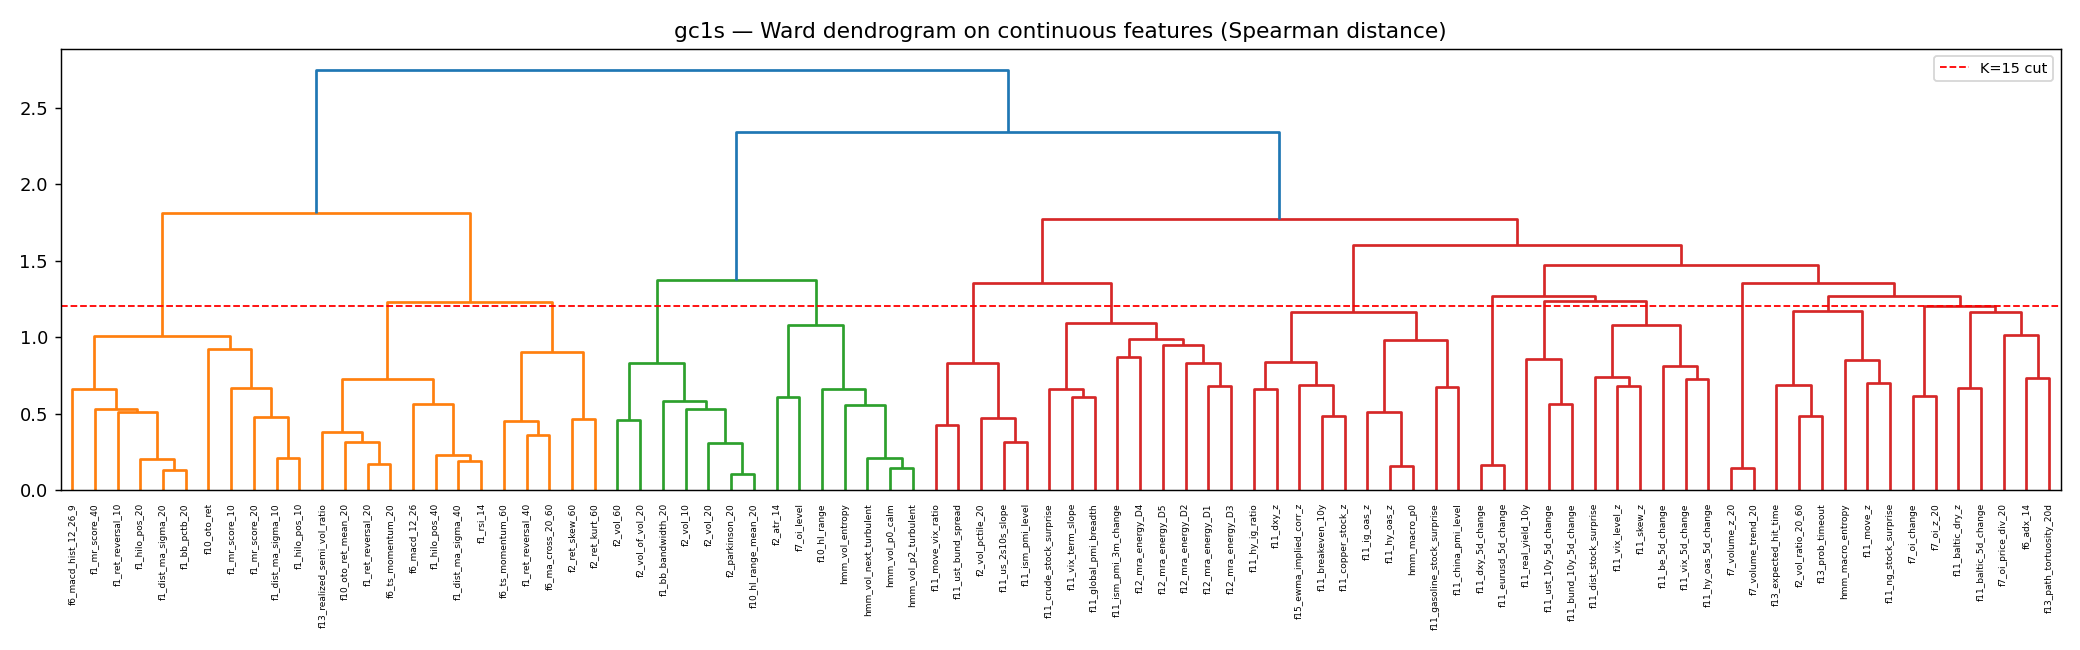

In [4]:
show_step1('gc1s')

#### Step 2 · Cluster-level importance

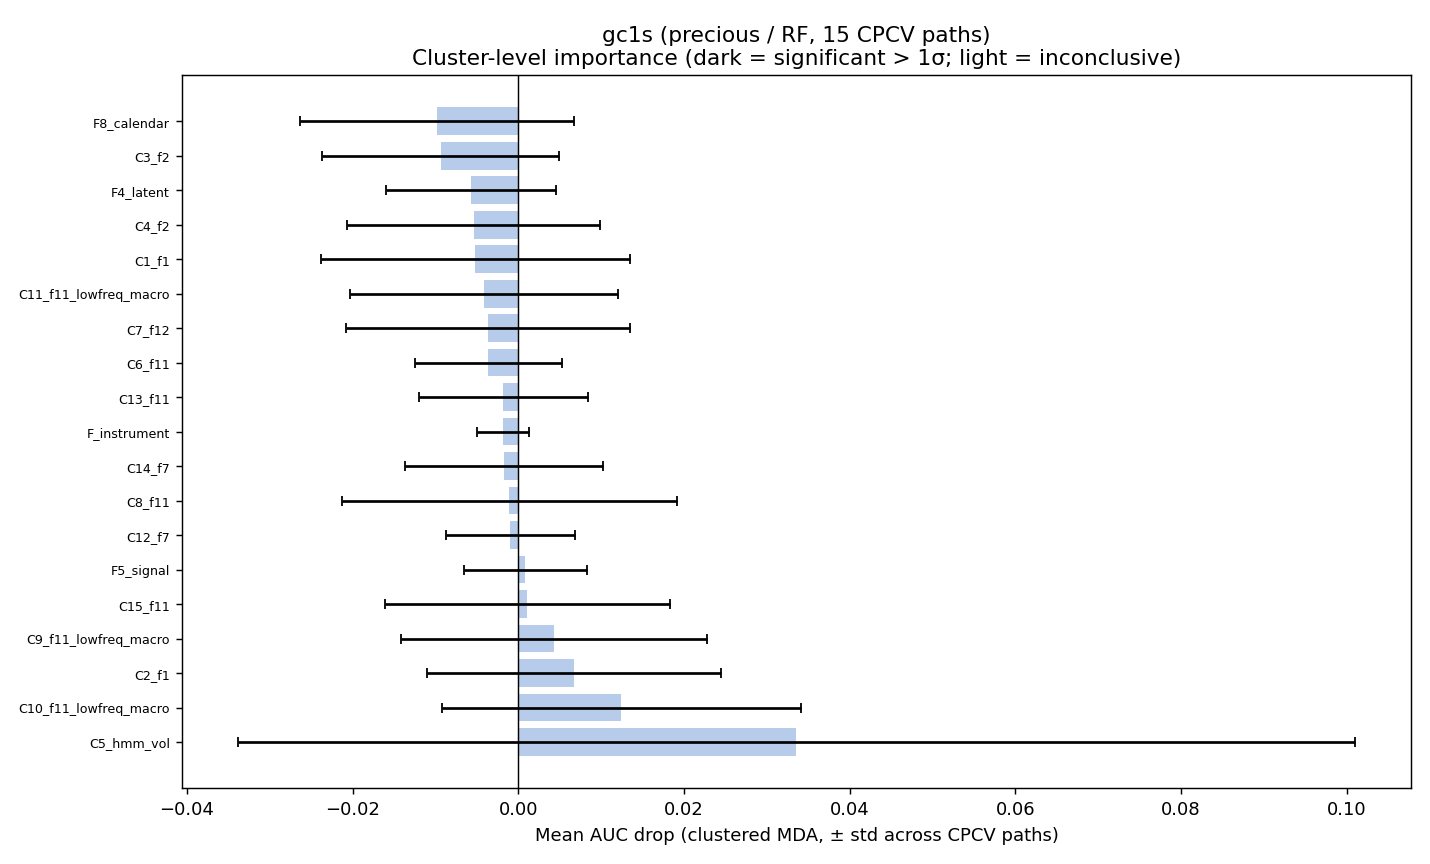

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,C5_hmm_vol,0.0336,1,0.2169,1,0.0332,1,False
1,C10_f11_lowfreq_macro,0.0124,2,0.0440,10,0.0063,8,False
2,C2_f1,0.0067,3,0.0785,3,0.0066,7,False
3,C9_f11_lowfreq_macro,0.0043,4,0.0348,12,0.0043,12,False
4,C15_f11,0.0011,5,0.0599,6,0.0067,6,False
5,F5_signal,0.0008,6,0.0150,16,0.0025,16,False
6,C12_f7,-0.0010,7,0.0143,18,0.0018,18,False
7,C8_f11,-0.0011,8,0.0700,4,0.0099,2,False
8,C14_f7,-0.0017,9,0.0246,15,0.0037,14,False
9,F_instrument,-0.0018,10,0.0086,19,0.0016,19,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.12,False
1,MDA-SHAP,0.13,False
2,MDI-SHAP,0.87,True


In [5]:
show_step2('gc1s')

#### Step 3 · Within-cluster breakdown (top 3, significant first)

Step-3 clusters (significant first): ['C5_hmm_vol', 'C10_f11_lowfreq_macro', 'C2_f1']


,feature,mean_shap_mag,pc1_loading
0,f2_atr_14,0.0020,0.393
1,f7_oi_level,0.0019,-0.315
2,f10_hl_range,0.0022,0.303
3,hmm_vol_p0_calm,0.0085,-0.167
4,hmm_vol_p2_turbulent,0.0079,0.507
5,hmm_vol_next_turbulent,0.0079,0.501
6,hmm_vol_entropy,0.0030,-0.344


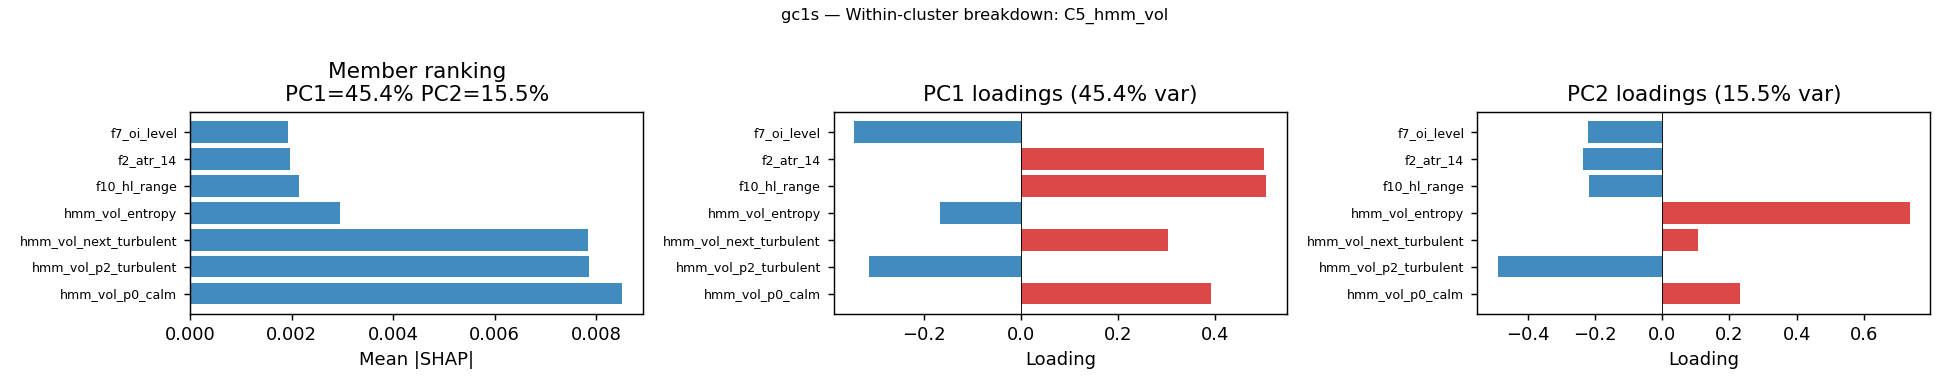

,feature,mean_shap_mag,pc1_loading
0,f11_ust_10y_5d_change,0.0037,0.631
1,f11_bund_10y_5d_change,0.0020,0.595
2,f11_real_yield_10y,0.0007,0.498


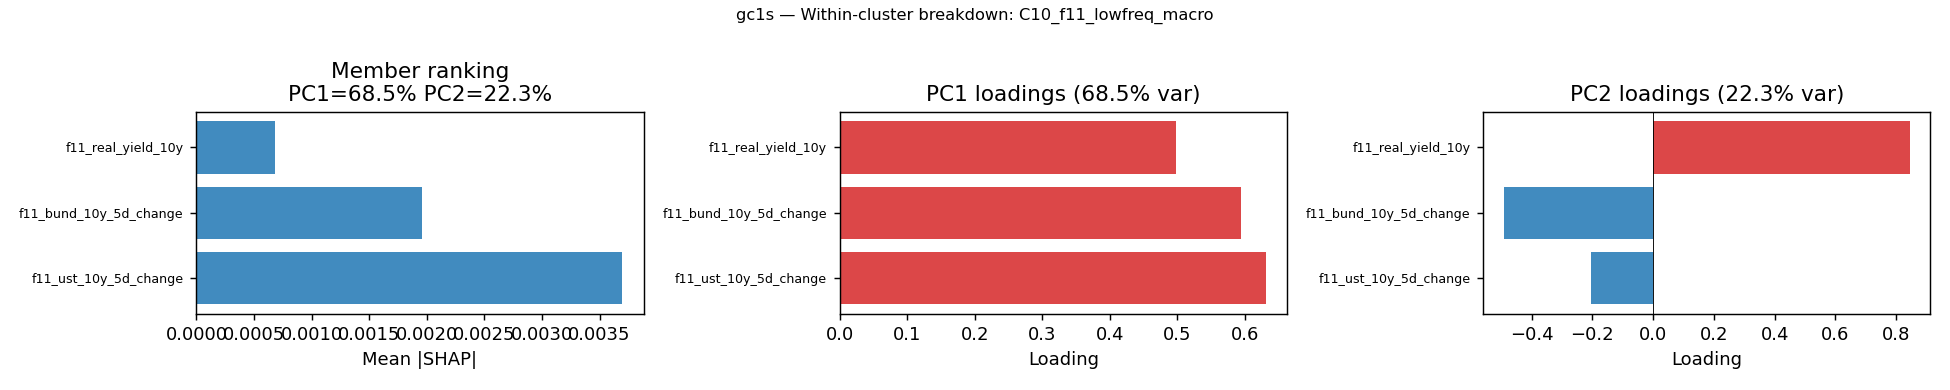

,feature,mean_shap_mag,pc1_loading
0,f1_ret_reversal_20,0.0008,-0.369
1,f1_dist_ma_sigma_40,0.0005,0.371
2,f1_hilo_pos_40,0.0006,0.353
3,f1_rsi_14,0.0007,0.379
4,f6_ts_momentum_20,0.0011,0.386
5,f6_macd_12_26,0.0009,0.268
6,f10_oto_ret_mean_20,0.0010,0.354
7,f13_realized_semi_vol_ratio,0.0009,0.335


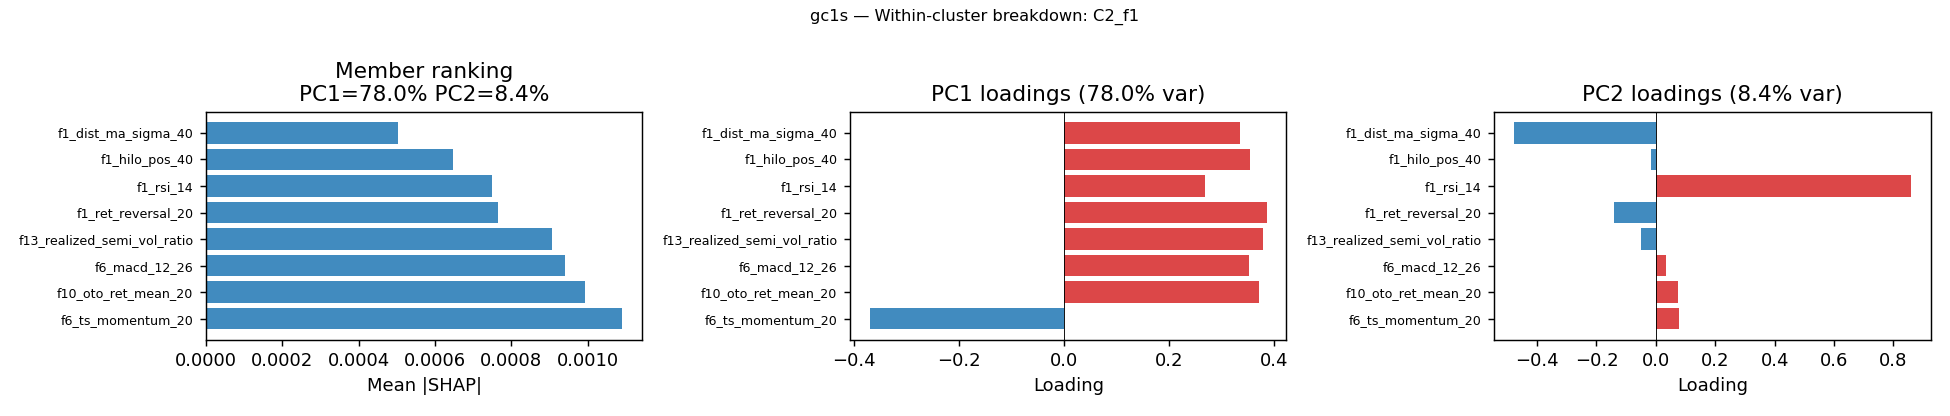

In [6]:
show_step3('gc1s')

#### Step 5 · Global feature importance

,feature,shap_magnitude,shap_signed,mdi
0,hmm_vol_p0_calm,0.0085,-0.0007,0.0432
1,hmm_vol_p2_turbulent,0.0079,-0.0017,0.0427
2,hmm_vol_next_turbulent,0.0079,-0.0015,0.0463
3,f11_ust_10y_5d_change,0.0037,0.0001,0.0219
4,hmm_vol_entropy,0.0030,-0.0006,0.0278
5,f6_adx_14,0.0029,-0.0018,0.0307
6,f11_eurusd_5d_change,0.0026,0.0000,0.0206
7,f7_oi_z_20,0.0026,-0.0005,0.0172
8,f4_pc2,0.0025,-0.0010,0.0187
9,f11_copper_stock_z,0.0023,0.0012,0.0109


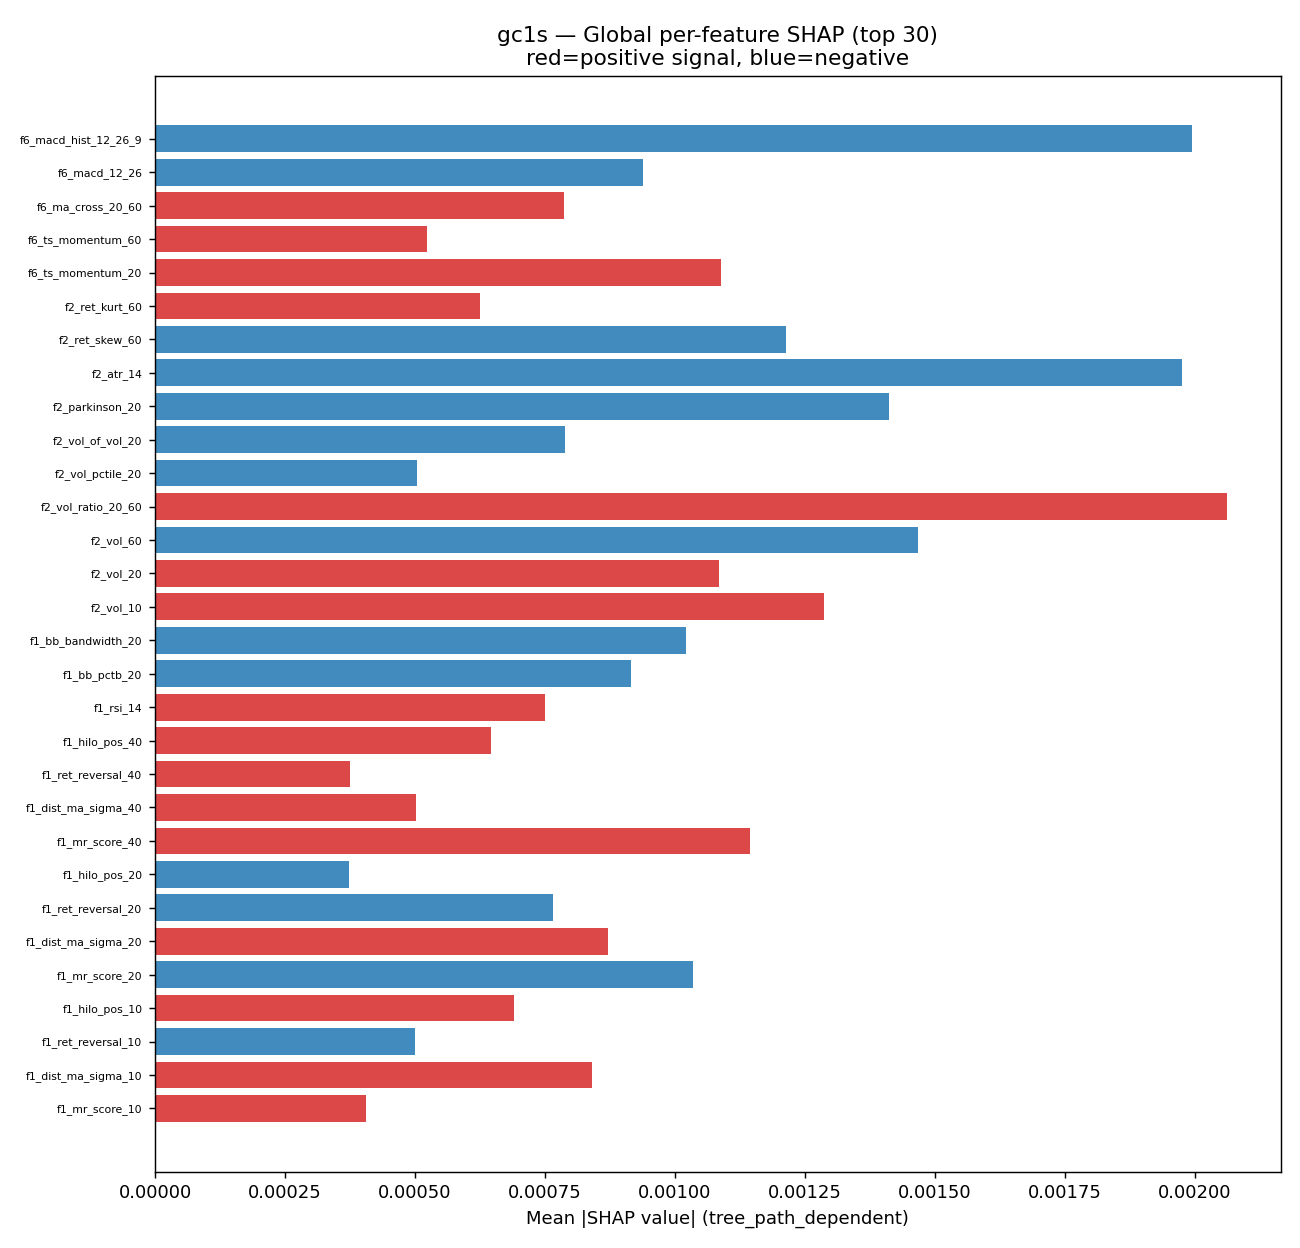

In [7]:
show_step5('gc1s')

---
### SI1S — Steps 1–5

In [8]:
meta = print_header('si1s')

--- SI1S | group=precious | champion=RF | family=tree ---
CPCV: 15 paths  AUC 0.5400 ± 0.0638  NO SIGNAL (lower CI 0.4762)
Significant clusters: none


#### Step 1 · Feature clusters

,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
10,C5_hmm_vol,7,hmm_,57%,0.0408,0.0520,False
5,C15_f11_lowfreq_macro,5,f11_,100%,0.0080,0.0107,False
3,C13_f11_lowfreq_macro,2,f11_,100%,0.0047,0.0069,False
14,C9_f13,3,f13_,67%,0.0023,0.0053,False
0,C10_f7,2,f7_,100%,0.0003,0.0055,False
16,F5_signal,5,f5_,100%,-0.0001,0.0046,False
2,C12_f11,10,f11_,80%,-0.0001,0.0064,False
9,C4_f2,7,f2_,71%,-0.0001,0.0062,False
8,C3_f2,5,f2_,40%,-0.0002,0.0043,False
15,F4_latent,4,f4_,100%,-0.0003,0.0037,False


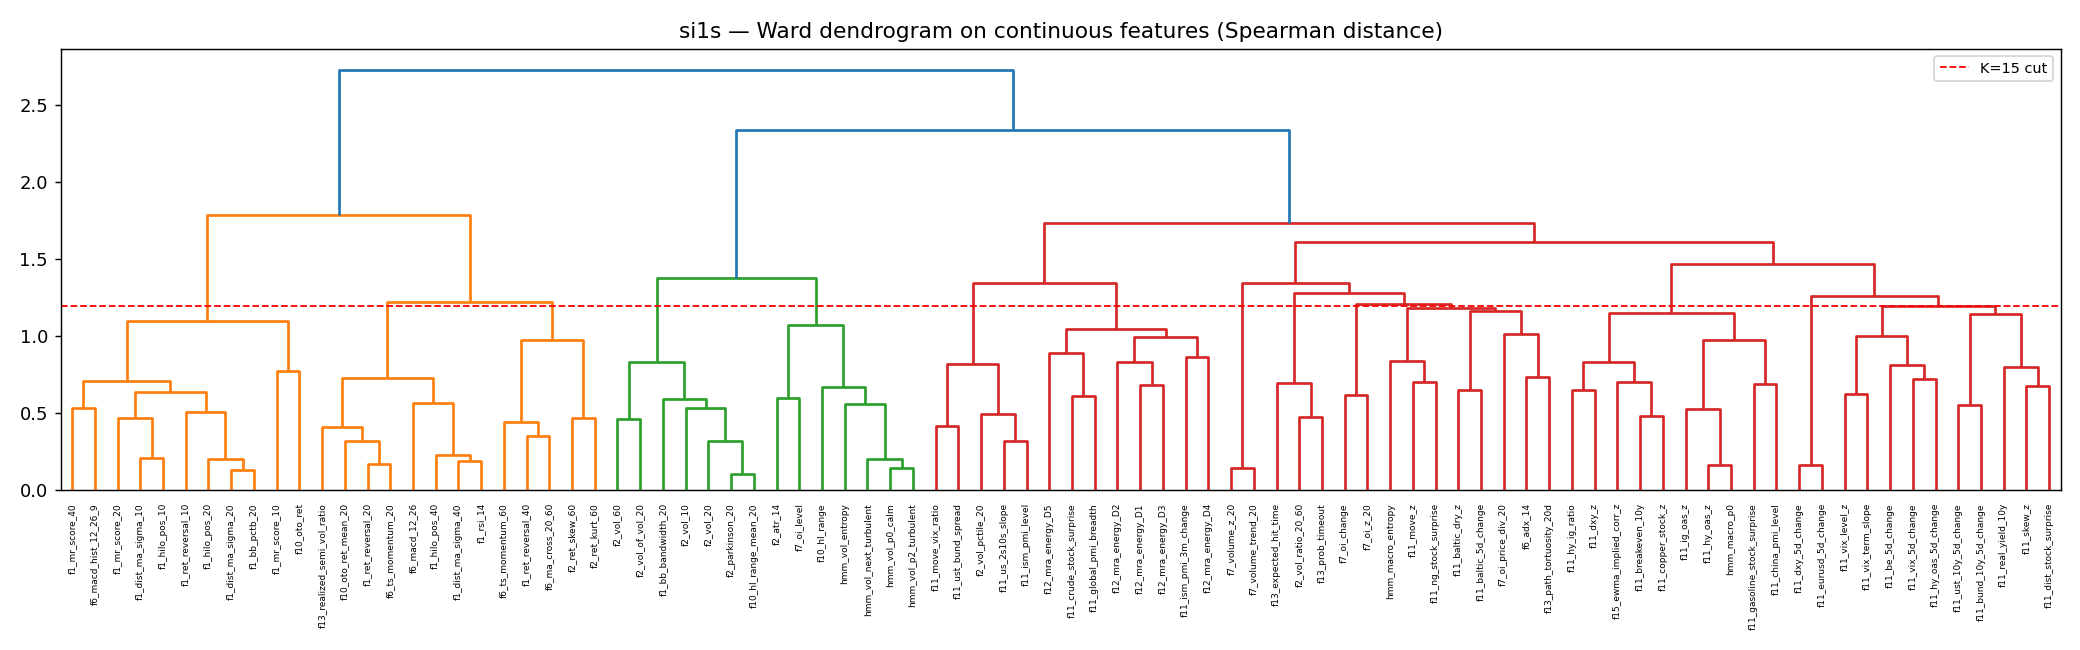

In [9]:
show_step1('si1s')

#### Step 2 · Cluster-level importance

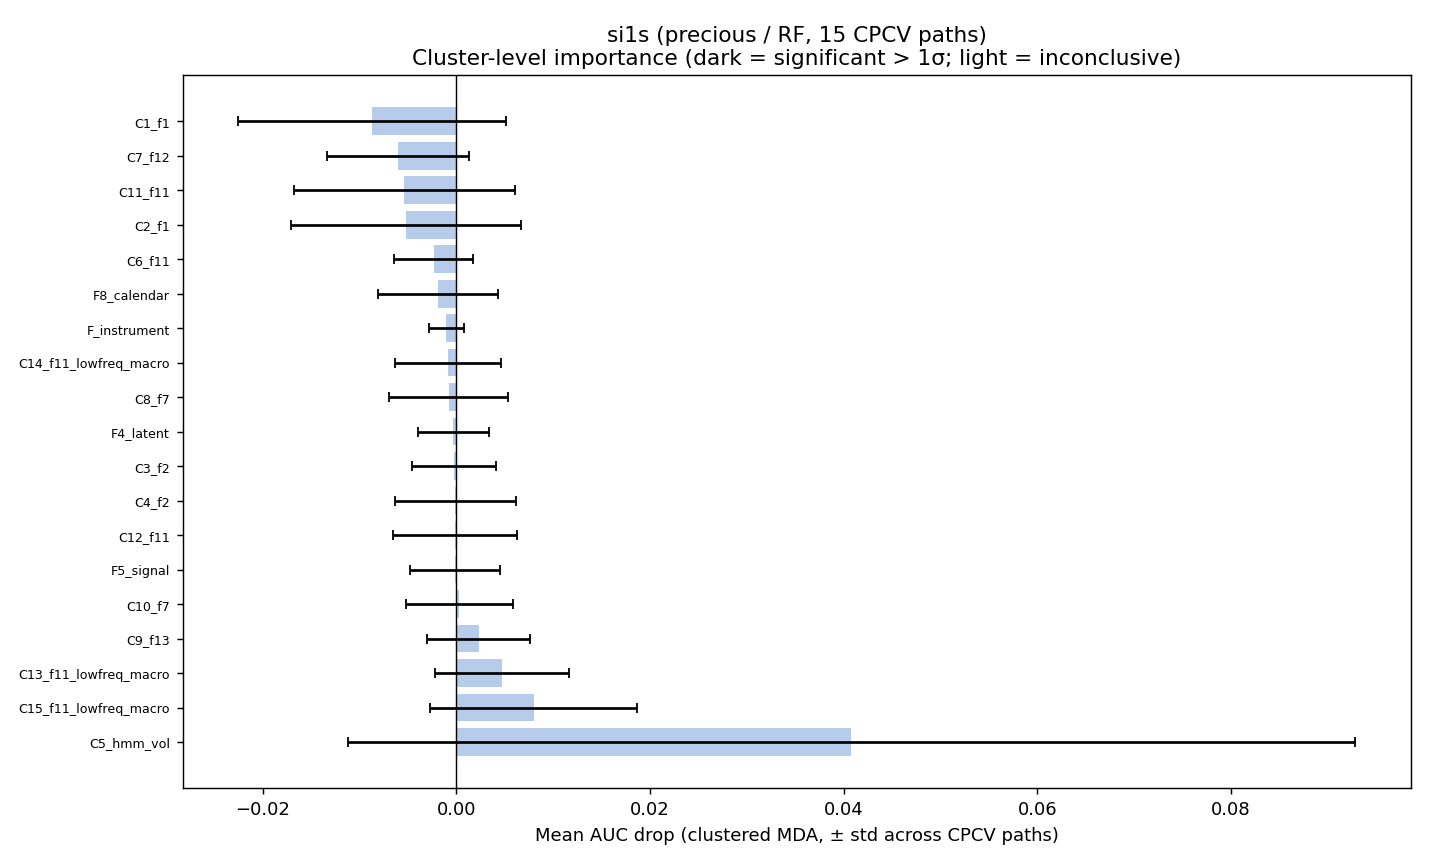

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,C5_hmm_vol,0.0408,1,0.2169,1,0.0398,1,False
1,C15_f11_lowfreq_macro,0.0080,2,0.0616,7,0.0090,5,False
2,C13_f11_lowfreq_macro,0.0047,3,0.0348,11,0.0041,11,False
3,C9_f13,0.0023,4,0.0202,15,0.0033,15,False
4,C10_f7,0.0003,5,0.0246,14,0.0034,14,False
5,F5_signal,-0.0001,6,0.0150,16,0.0020,18,False
6,C12_f11,-0.0001,7,0.0700,5,0.0099,2,False
7,C4_f2,-0.0001,8,0.0675,6,0.0076,6,False
8,C3_f2,-0.0002,9,0.0322,12,0.0039,12,False
9,F4_latent,-0.0003,10,0.0505,9,0.0058,9,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,-0.05,False
1,MDA-SHAP,-0.01,False
2,MDI-SHAP,0.88,True


In [10]:
show_step2('si1s')

#### Step 3 · Within-cluster breakdown (top 3, significant first)

Step-3 clusters (significant first): ['C5_hmm_vol', 'C15_f11_lowfreq_macro', 'C13_f11_lowfreq_macro']


,feature,mean_shap_mag,pc1_loading
0,f2_atr_14,0.0054,0.393
1,f7_oi_level,0.0021,-0.315
2,f10_hl_range,0.0012,0.303
3,hmm_vol_p0_calm,0.0101,-0.167
4,hmm_vol_p2_turbulent,0.0091,0.507
5,hmm_vol_next_turbulent,0.0088,0.501
6,hmm_vol_entropy,0.0031,-0.344


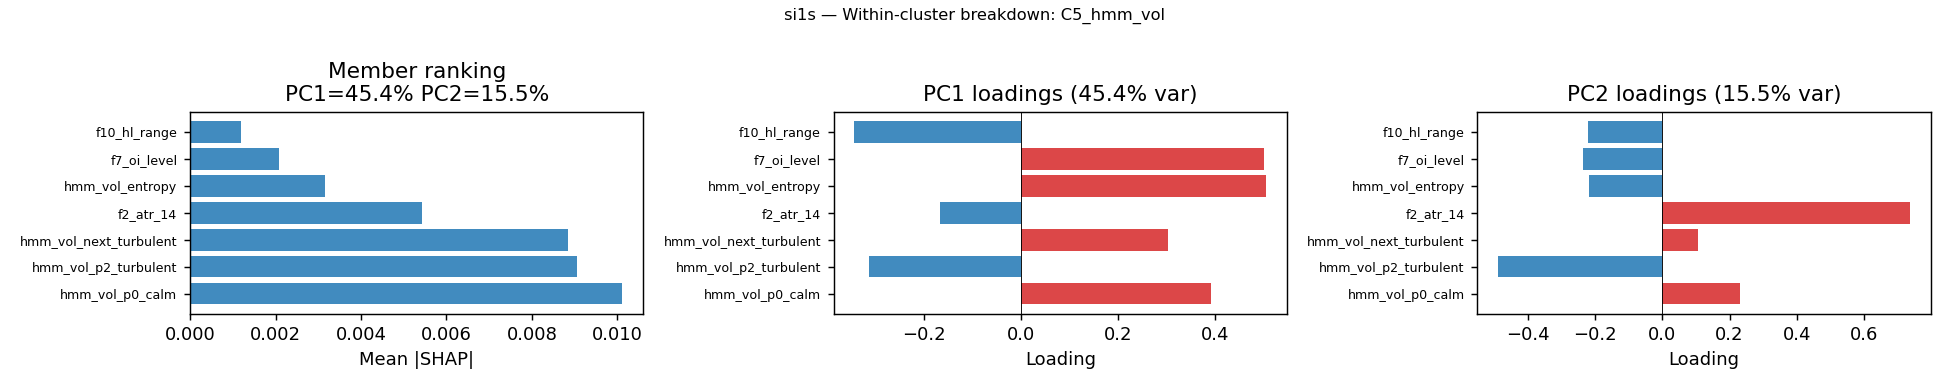

,feature,mean_shap_mag,pc1_loading
0,f11_skew_z,0.0006,-0.352
1,f11_ust_10y_5d_change,0.0038,0.477
2,f11_bund_10y_5d_change,0.0021,0.472
3,f11_real_yield_10y,0.0006,0.535
4,f11_dist_stock_surprise,0.0019,-0.374


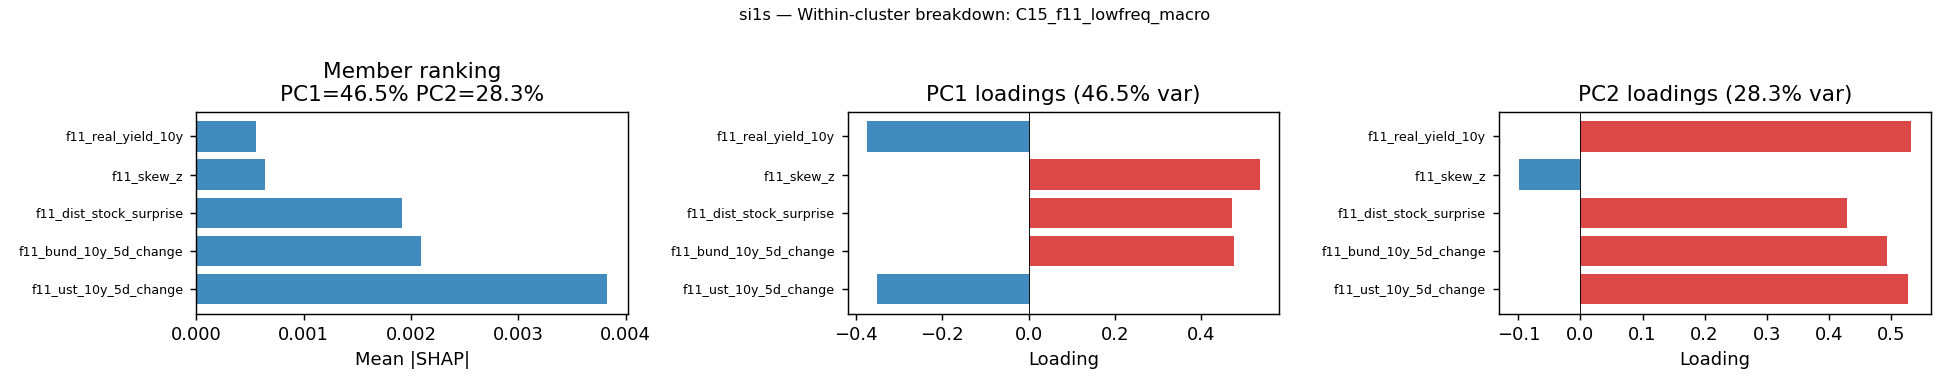

,feature,mean_shap_mag,pc1_loading
0,f11_dxy_5d_change,0.0016,-0.707
1,f11_eurusd_5d_change,0.0025,0.707


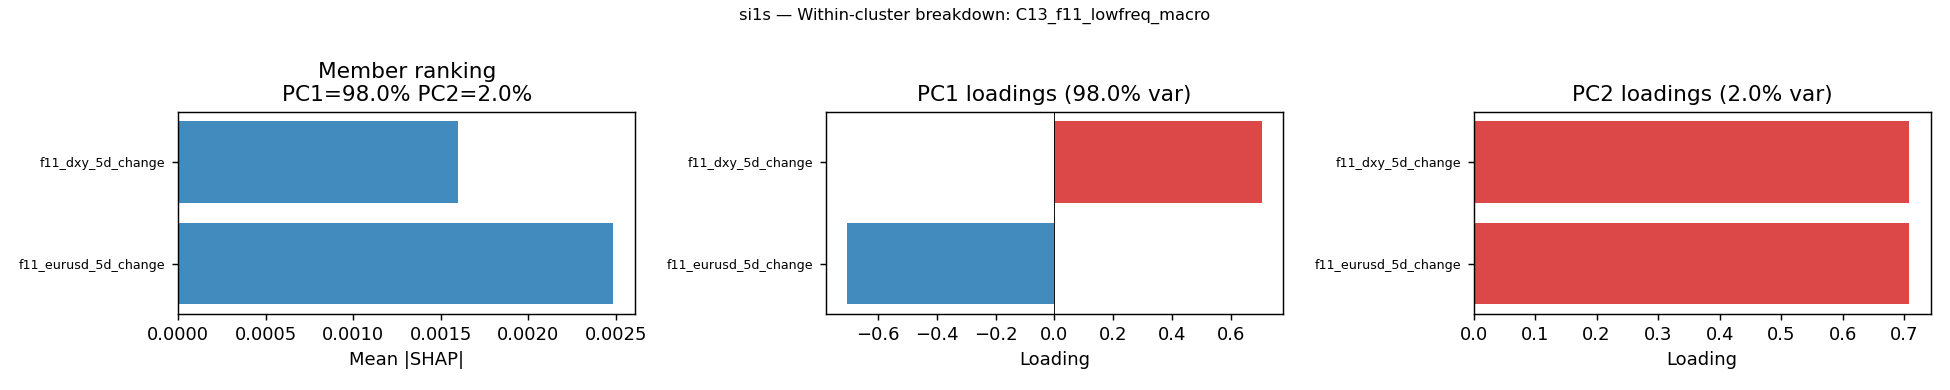

In [11]:
show_step3('si1s')

#### Step 5 · Global feature importance

,feature,shap_magnitude,shap_signed,mdi
0,hmm_vol_p0_calm,0.0101,-0.0040,0.0432
1,hmm_vol_p2_turbulent,0.0091,-0.0036,0.0427
2,hmm_vol_next_turbulent,0.0088,-0.0035,0.0463
3,f2_atr_14,0.0054,-0.0054,0.0301
4,f11_ust_10y_5d_change,0.0038,-0.0005,0.0219
5,hmm_vol_entropy,0.0031,-0.0009,0.0278
6,f6_adx_14,0.0031,-0.0017,0.0307
7,f11_eurusd_5d_change,0.0025,-0.0002,0.0206
8,f4_pc2,0.0025,-0.0005,0.0187
9,f7_oi_z_20,0.0025,-0.0005,0.0172


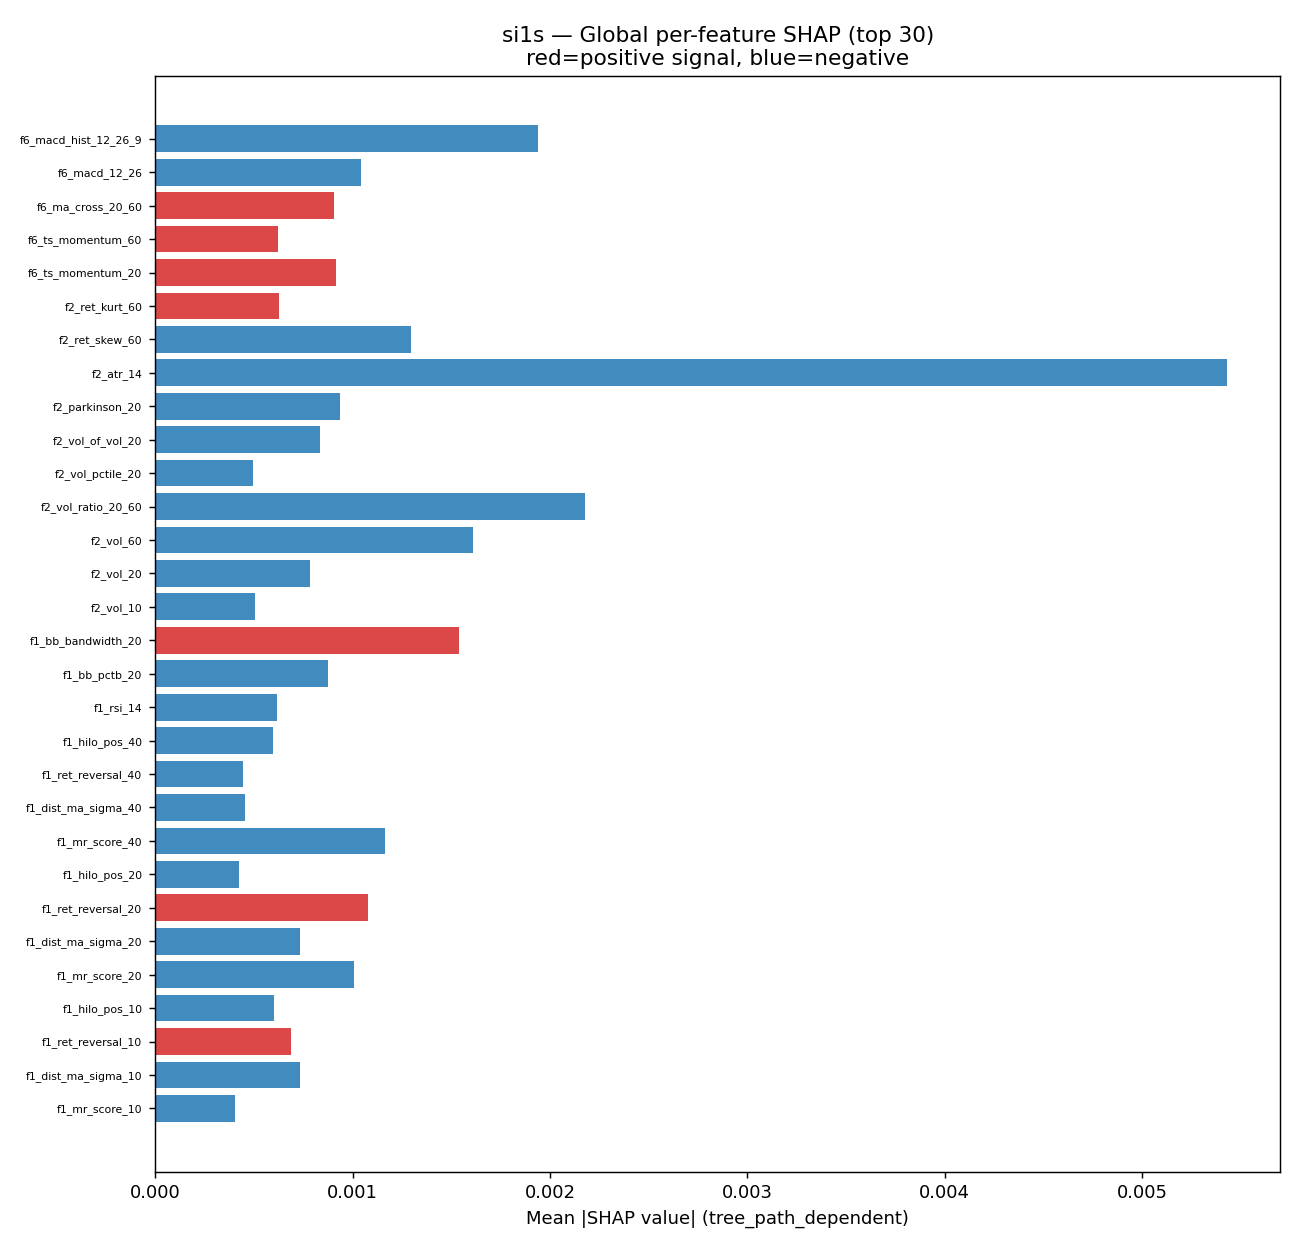

In [12]:
show_step5('si1s')

---
### PL1S — Steps 1–5

In [13]:
meta = print_header('pl1s')

--- PL1S | group=precious | champion=RF | family=tree ---
CPCV: 15 paths  AUC 0.5697 ± 0.0301  SIGNAL (lower CI 0.5396)
Significant clusters: C5_hmm_vol (MDA 0.0447 ± 0.0318), C11_f11 (MDA 0.0152 ± 0.0142)


#### Step 1 · Feature clusters

,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
10,C5_hmm_vol,7,hmm_,57%,0.0447,0.0318,True
1,C11_f11,8,f11_,50%,0.0152,0.0142,True
5,C15_f11_lowfreq_macro,5,f11_,100%,0.0113,0.0157,False
17,F8_calendar,4,f8_,100%,0.0053,0.0060,False
14,C9_f13,3,f13_,67%,0.0034,0.0051,False
2,C12_f11,10,f11_,80%,0.0032,0.0078,False
3,C13_f11_lowfreq_macro,2,f11_,100%,0.0020,0.0072,False
4,C14_f11_lowfreq_macro,5,f11_,100%,0.0009,0.0079,False
7,C2_f1,8,f1_,50%,0.0008,0.0086,False
9,C4_f2,7,f2_,71%,0.0006,0.0141,False


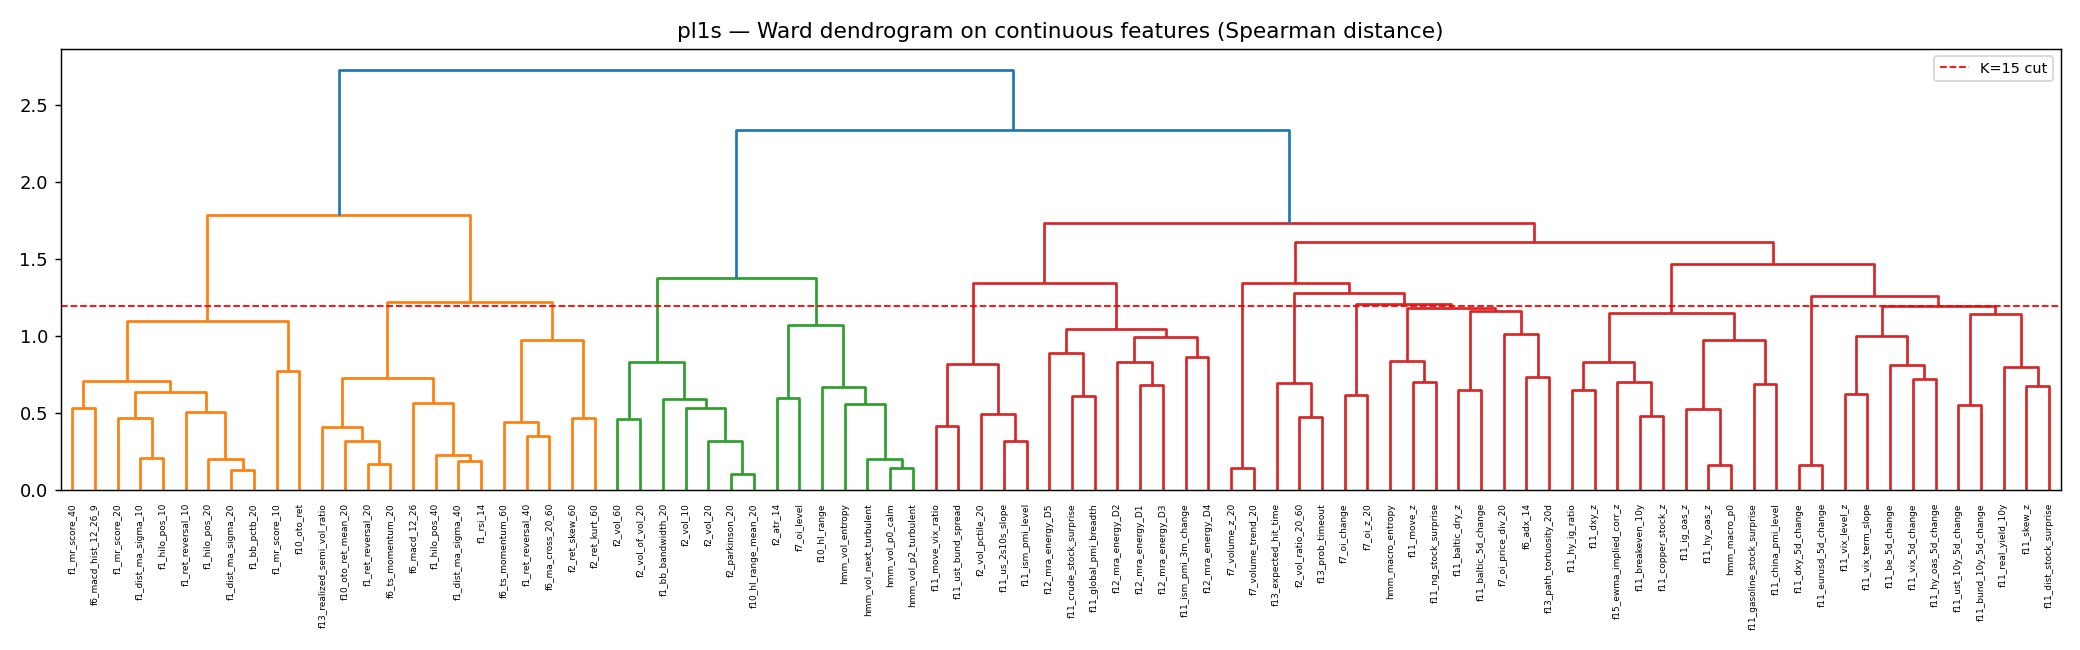

In [14]:
show_step1('pl1s')

#### Step 2 · Cluster-level importance

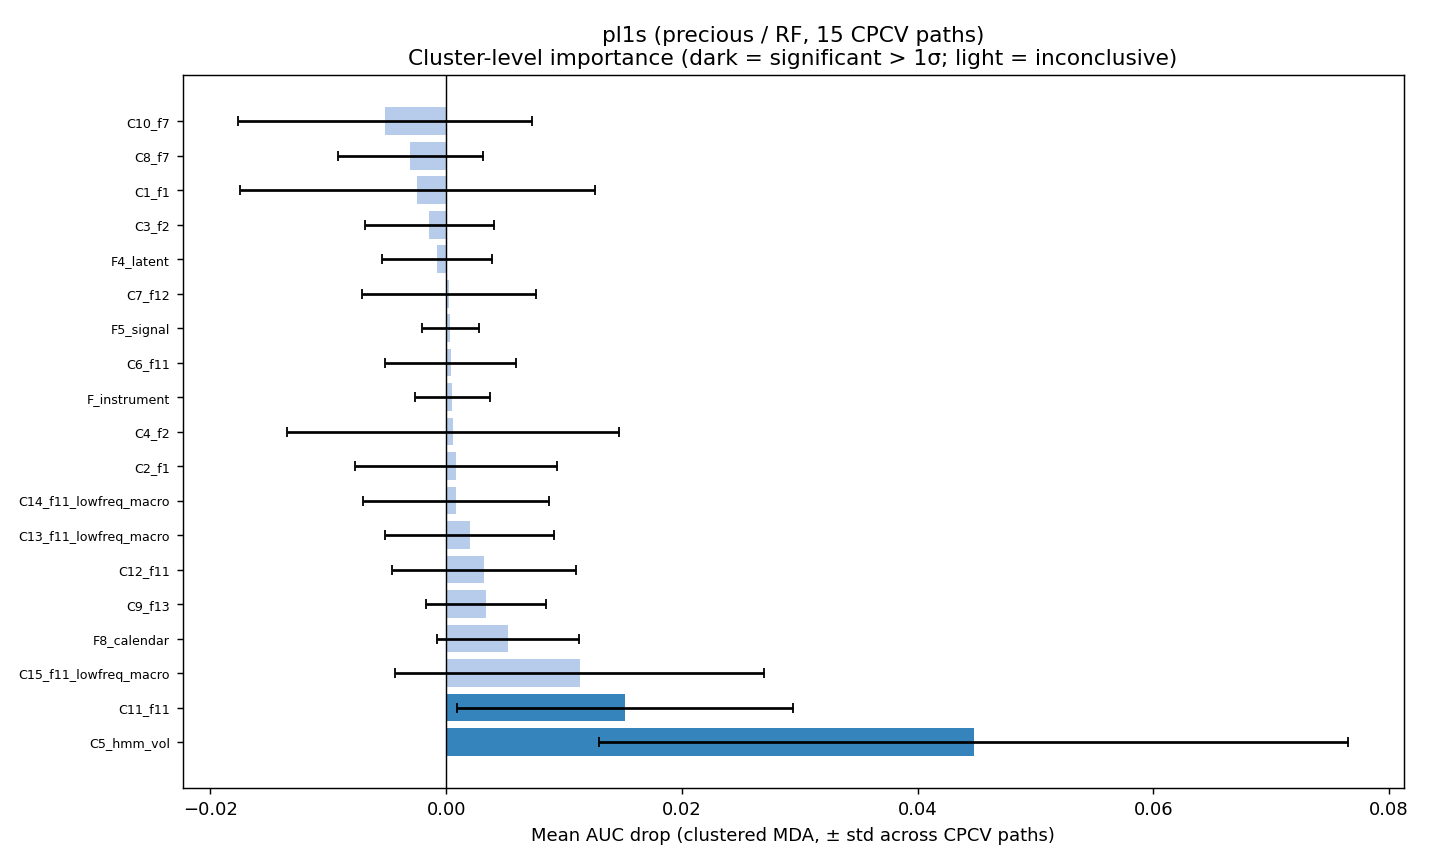

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,C5_hmm_vol,0.0447,1,0.2169,1,0.0293,1,True
1,C11_f11,0.0152,2,0.0831,3,0.0134,2,True
2,C15_f11_lowfreq_macro,0.0113,3,0.0616,7,0.0093,5,False
3,F8_calendar,0.0053,4,0.0145,17,0.0025,16,False
4,C9_f13,0.0034,5,0.0202,15,0.0030,15,False
5,C12_f11,0.0032,6,0.0700,5,0.0096,4,False
6,C13_f11_lowfreq_macro,0.0020,7,0.0348,11,0.0040,11,False
7,C14_f11_lowfreq_macro,0.0009,8,0.0382,10,0.0046,10,False
8,C2_f1,0.0008,9,0.0785,4,0.0076,6,False
9,C4_f2,0.0006,10,0.0675,6,0.0072,7,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.24,False
1,MDA-SHAP,0.31,False
2,MDI-SHAP,0.93,True


In [15]:
show_step2('pl1s')

#### Step 3 · Within-cluster breakdown (top 3, significant first)

Step-3 clusters (significant first): ['C5_hmm_vol', 'C11_f11', 'C15_f11_lowfreq_macro']


,feature,mean_shap_mag,pc1_loading
0,f2_atr_14,0.0041,0.393
1,f7_oi_level,0.0019,-0.315
2,f10_hl_range,0.0011,0.303
3,hmm_vol_p0_calm,0.0069,-0.167
4,hmm_vol_p2_turbulent,0.0063,0.507
5,hmm_vol_next_turbulent,0.0066,0.501
6,hmm_vol_entropy,0.0024,-0.344


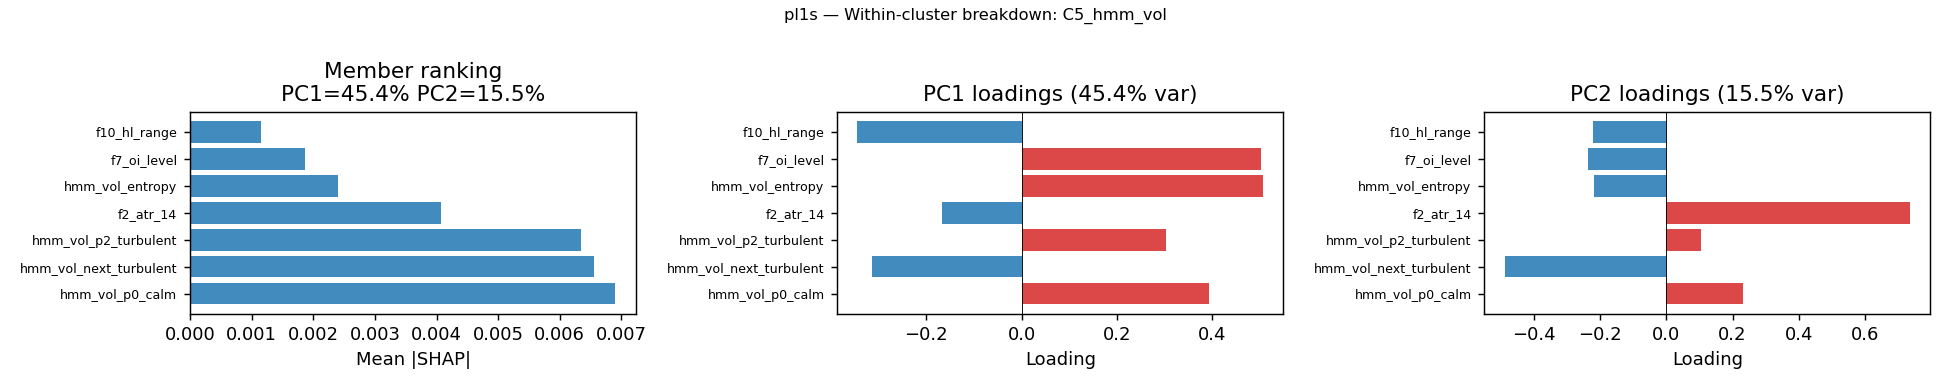

,feature,mean_shap_mag,pc1_loading
0,f6_adx_14,0.0072,0.094
1,f7_oi_price_div_20,0.0006,-0.077
2,f11_move_z,0.0006,-0.355
3,f11_ng_stock_surprise,0.0009,0.481
4,f11_baltic_dry_z,0.0009,0.590
5,f11_baltic_5d_change,0.0008,0.511
6,f13_path_tortuosity_20d,0.0013,-0.100
7,hmm_macro_entropy,0.0011,0.094


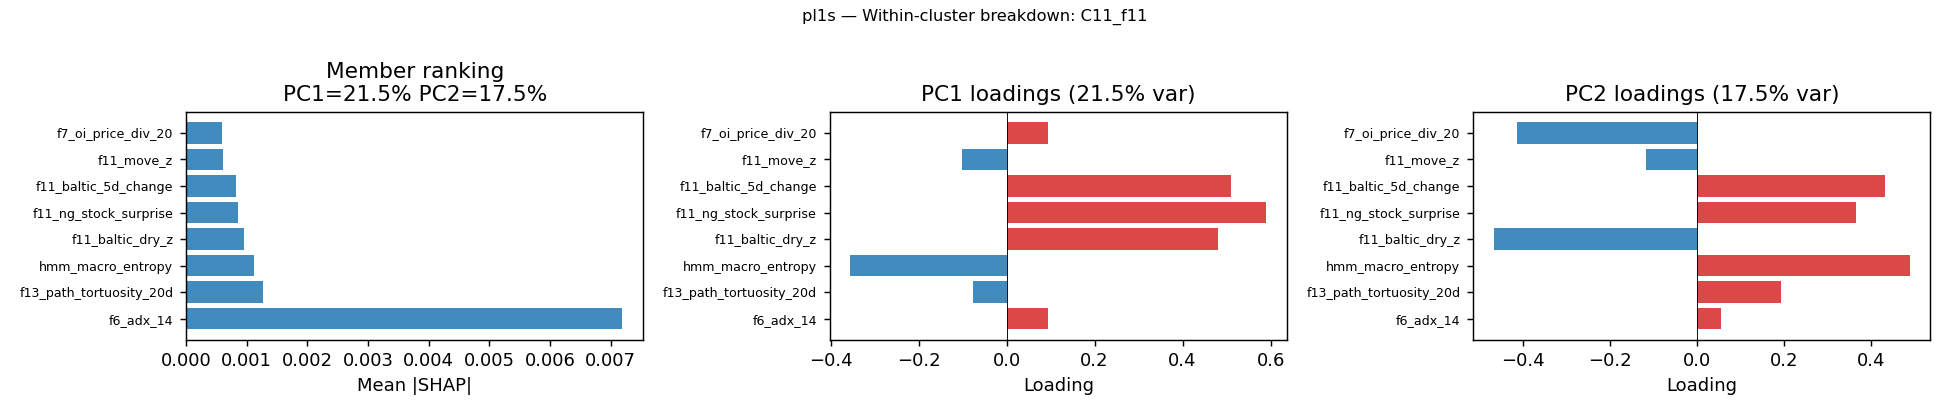

,feature,mean_shap_mag,pc1_loading
0,f11_skew_z,0.0006,-0.352
1,f11_ust_10y_5d_change,0.0038,0.477
2,f11_bund_10y_5d_change,0.0022,0.472
3,f11_real_yield_10y,0.0005,0.535
4,f11_dist_stock_surprise,0.0022,-0.374


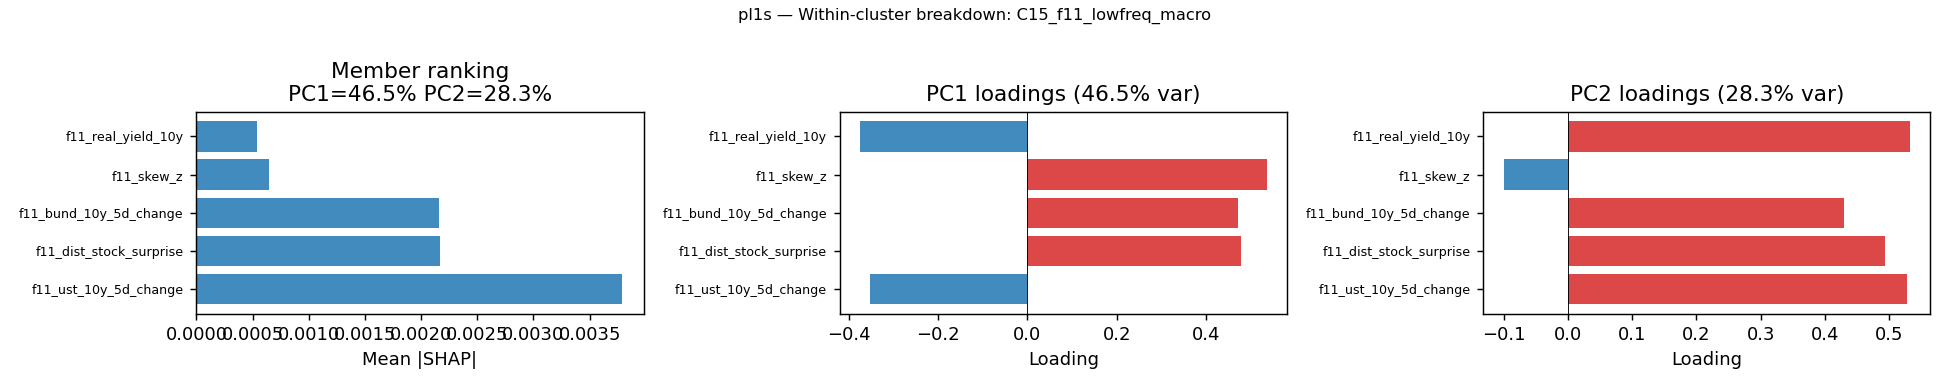

In [16]:
show_step3('pl1s')

#### Step 5 · Global feature importance

,feature,shap_magnitude,shap_signed,mdi
0,f6_adx_14,0.0072,0.0038,0.0307
1,hmm_vol_p0_calm,0.0069,0.0039,0.0432
2,hmm_vol_next_turbulent,0.0066,0.0039,0.0463
3,hmm_vol_p2_turbulent,0.0063,0.0038,0.0427
4,f2_atr_14,0.0041,0.0039,0.0301
5,f11_ust_10y_5d_change,0.0038,-0.0005,0.0219
6,f6_macd_hist_12_26_9,0.0032,0.0013,0.0226
7,f7_oi_z_20,0.0025,-0.0001,0.0172
8,hmm_vol_entropy,0.0024,0.0007,0.0278
9,f11_eurusd_5d_change,0.0024,-0.0001,0.0206


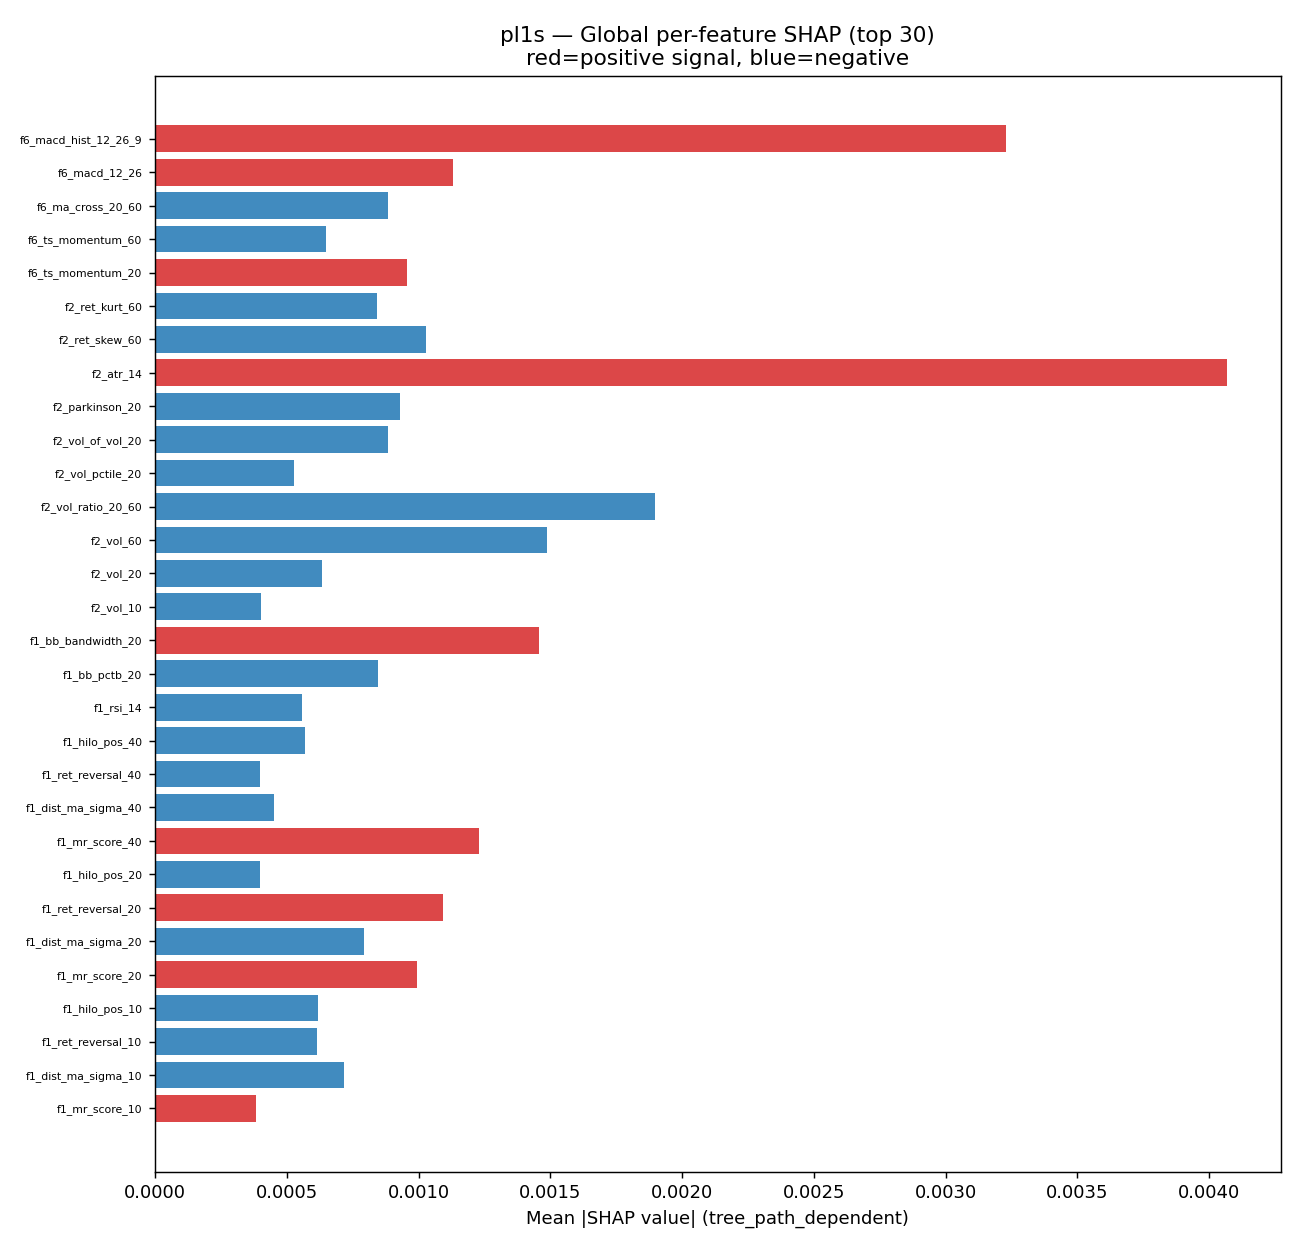

In [17]:
show_step5('pl1s')

---
### HG1S — Steps 1–5

In [18]:
meta = print_header('hg1s')

--- HG1S | group=hg1s | champion=RF | family=tree ---
CPCV: 15 paths  AUC 0.5463 ± 0.0405  SIGNAL (lower CI 0.5058)
Significant clusters: C1_f1 (MDA 0.0212 ± 0.0170), C12_f11 (MDA 0.0044 ± 0.0043)


#### Step 1 · Feature clusters

,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
6,C1_f1,10,f1_,80%,0.0212,0.0170,True
4,C14_f11,5,f11_,40%,0.0140,0.0141,False
2,C12_f11,5,f11_,80%,0.0044,0.0043,True
3,C13_f11,5,f11_,80%,0.0037,0.0057,False
7,C2_f1,13,f1_,38%,0.0035,0.0086,False
1,C11_f2,5,f2_,80%,0.0031,0.0092,False
5,C15_f12,5,f12_,60%,0.0019,0.0051,False
11,C6_f11,7,f11_,71%,0.0017,0.0054,False
17,F8_calendar,4,f8_,100%,-0.0001,0.0020,False
10,C5_f11_lowfreq_macro,2,f11_,100%,-0.0004,0.0039,False


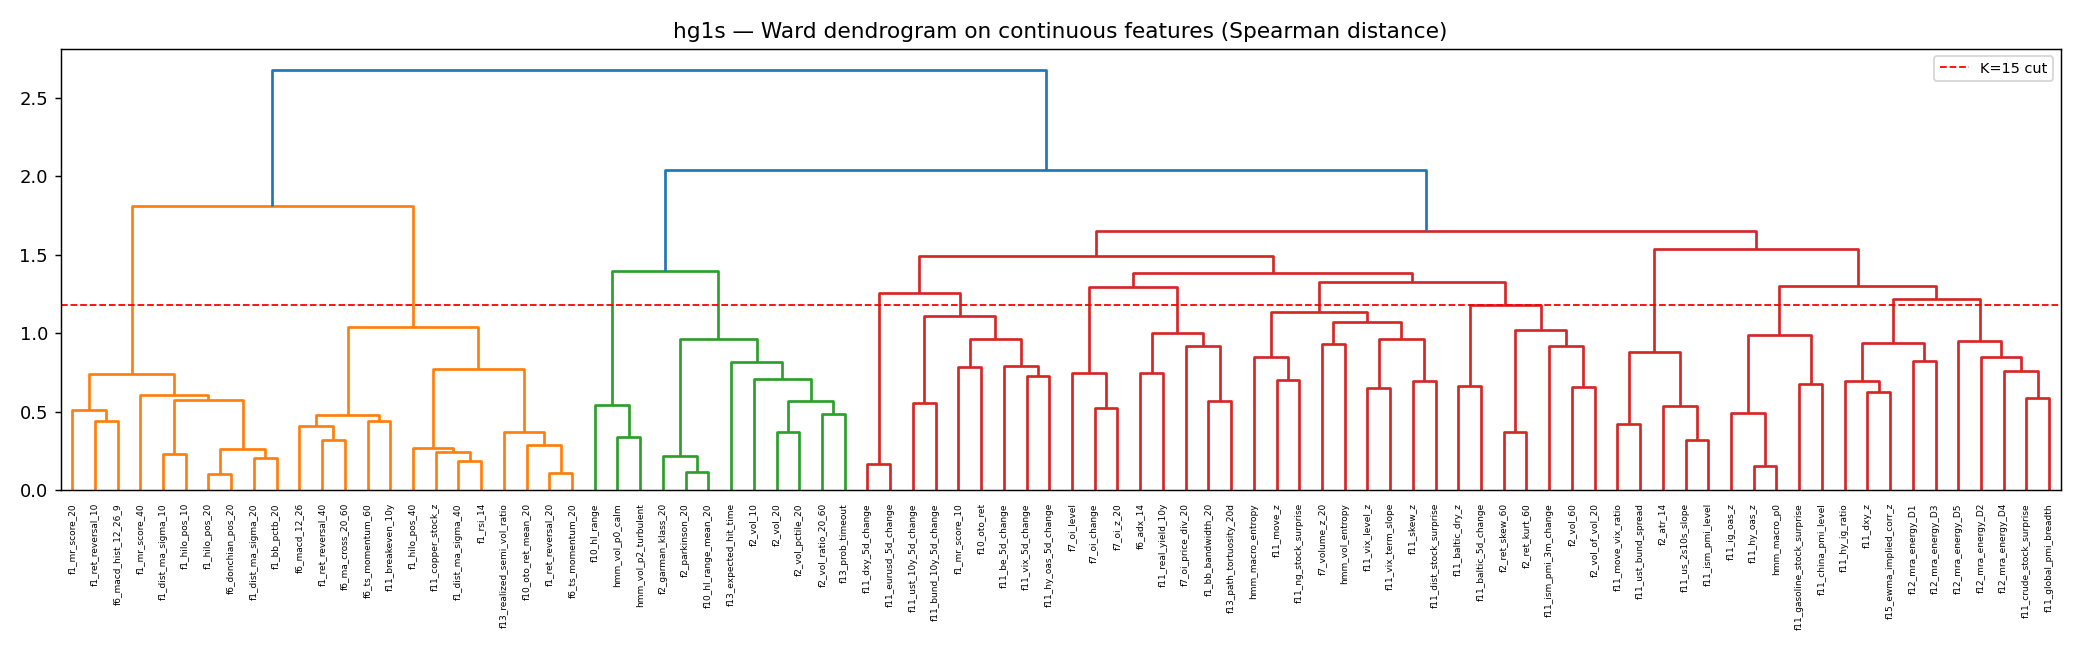

In [19]:
show_step1('hg1s')

#### Step 2 · Cluster-level importance

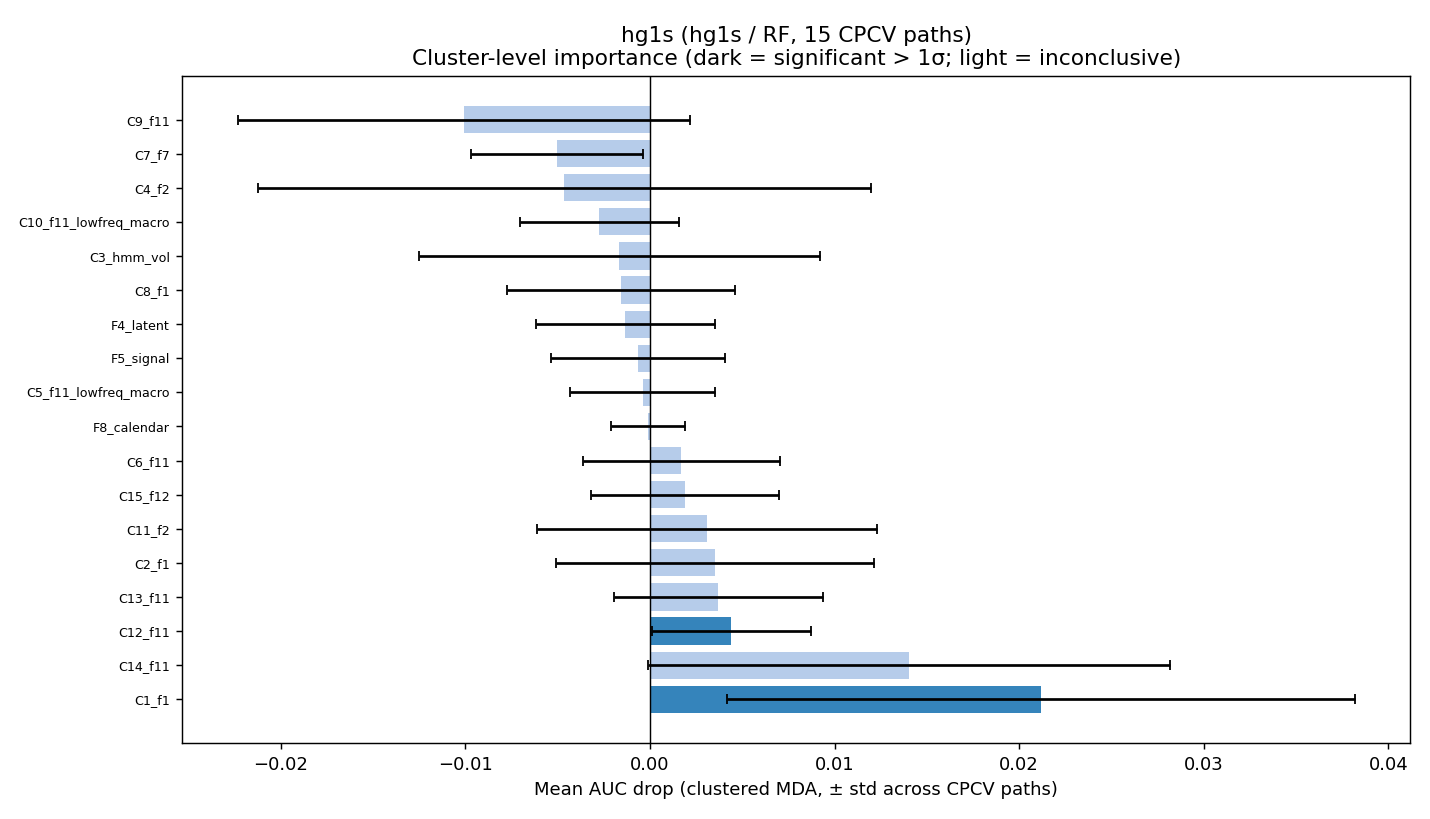

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,C1_f1,0.0212,1,0.1798,1,0.0315,1,True
1,C14_f11,0.0140,2,0.0775,4,0.0142,4,False
2,C12_f11,0.0044,3,0.0435,10,0.0080,10,True
3,C13_f11,0.0037,4,0.0452,9,0.0084,9,False
4,C2_f1,0.0035,5,0.1283,2,0.0238,2,False
5,C11_f2,0.0031,6,0.0581,7,0.0108,6,False
6,C15_f12,0.0019,7,0.0463,8,0.0093,7,False
7,C6_f11,0.0017,8,0.0589,6,0.0085,8,False
8,F8_calendar,-0.0001,9,0.0072,18,0.0015,18,False
9,C5_f11_lowfreq_macro,-0.0004,10,0.0191,15,0.0029,17,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.27,False
1,MDA-SHAP,0.28,False
2,MDI-SHAP,0.93,True


In [20]:
show_step2('hg1s')

#### Step 3 · Within-cluster breakdown (top 3, significant first)

Step-3 clusters (significant first): ['C1_f1', 'C12_f11', 'C14_f11']


,feature,mean_shap_mag,pc1_loading
0,f1_dist_ma_sigma_10,0.0038,0.326
1,f1_ret_reversal_10,0.0014,-0.311
2,f1_hilo_pos_10,0.0049,0.308
3,f1_mr_score_20,0.0013,-0.288
4,f1_dist_ma_sigma_20,0.0048,0.330
5,f1_hilo_pos_20,0.0033,0.331
6,f1_mr_score_40,0.0061,-0.299
7,f1_bb_pctb_20,0.0029,0.342
8,f6_macd_hist_12_26_9,0.0009,0.293
9,f6_donchian_pos_20,0.0021,0.330


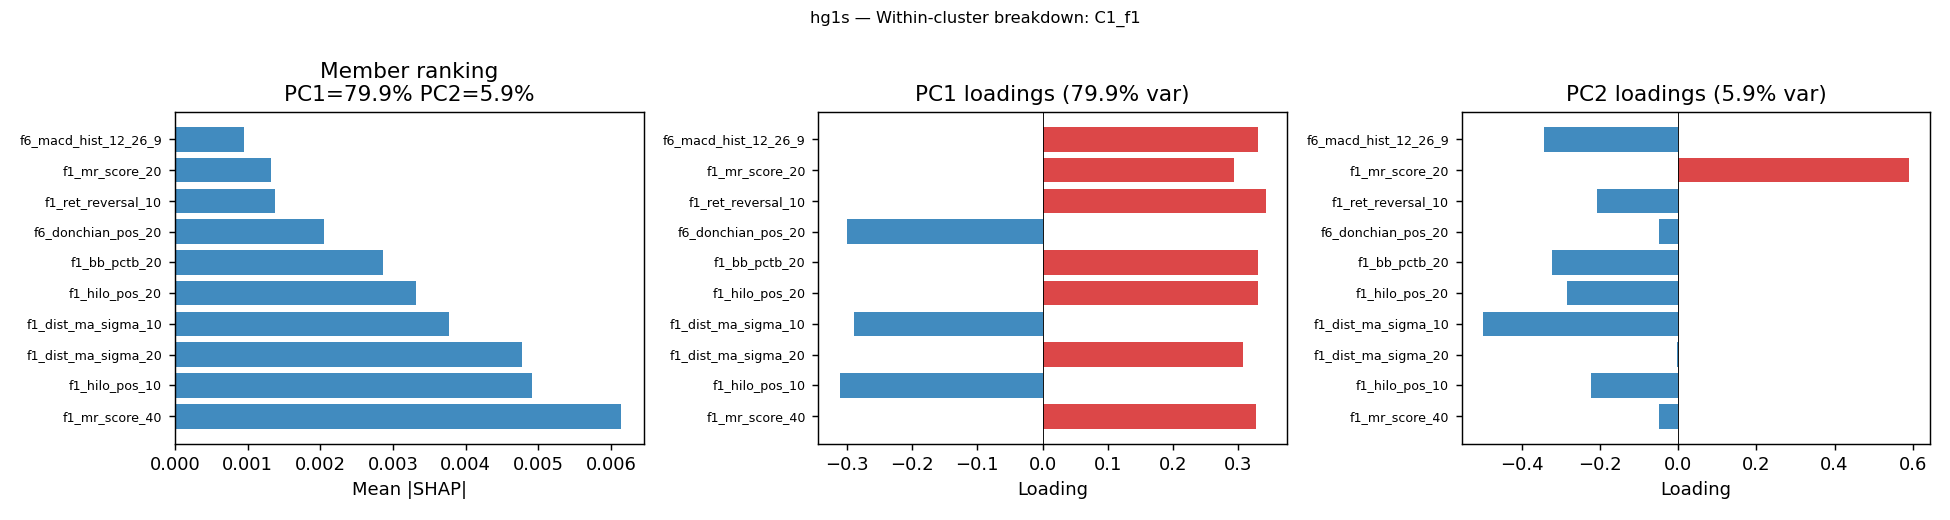

,feature,mean_shap_mag,pc1_loading
0,f2_atr_14,0.0014,0.434
1,f11_move_vix_ratio,0.0021,0.399
2,f11_us_2s10s_slope,0.0014,0.479
3,f11_ust_bund_spread,0.0023,0.465
4,f11_ism_pmi_level,0.0008,0.455


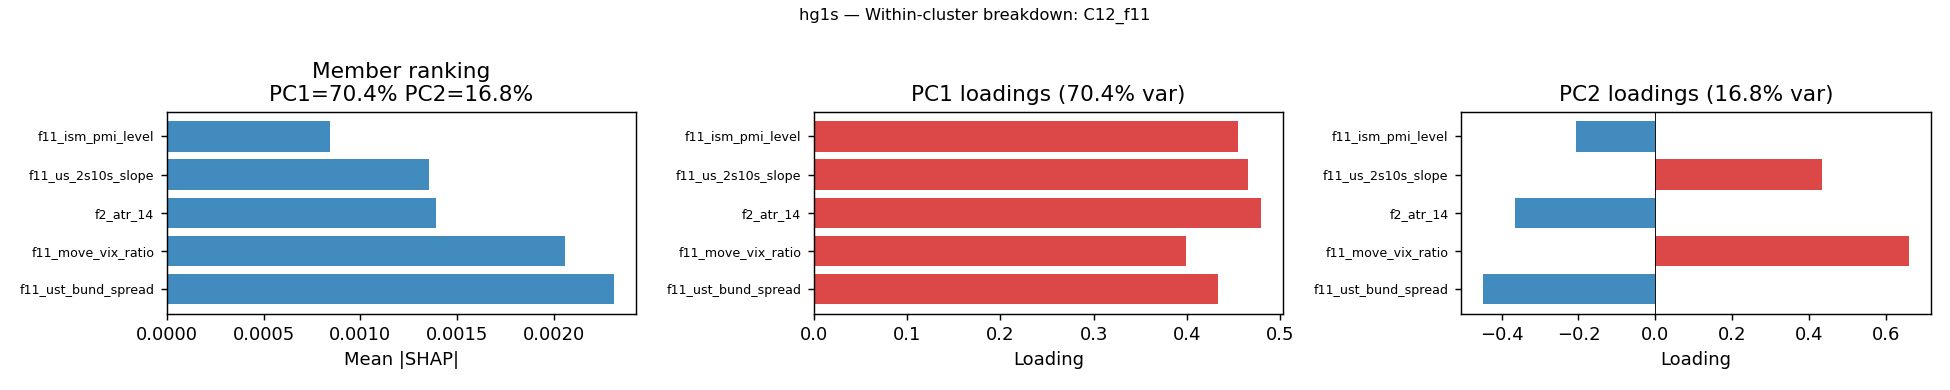

,feature,mean_shap_mag,pc1_loading
0,f11_hy_ig_ratio,0.0020,-0.467
1,f11_dxy_z,0.0034,0.484
2,f12_mra_energy_D1,0.0055,-0.414
3,f12_mra_energy_D3,0.0022,0.339
4,f15_ewma_implied_corr_z,0.0012,0.511


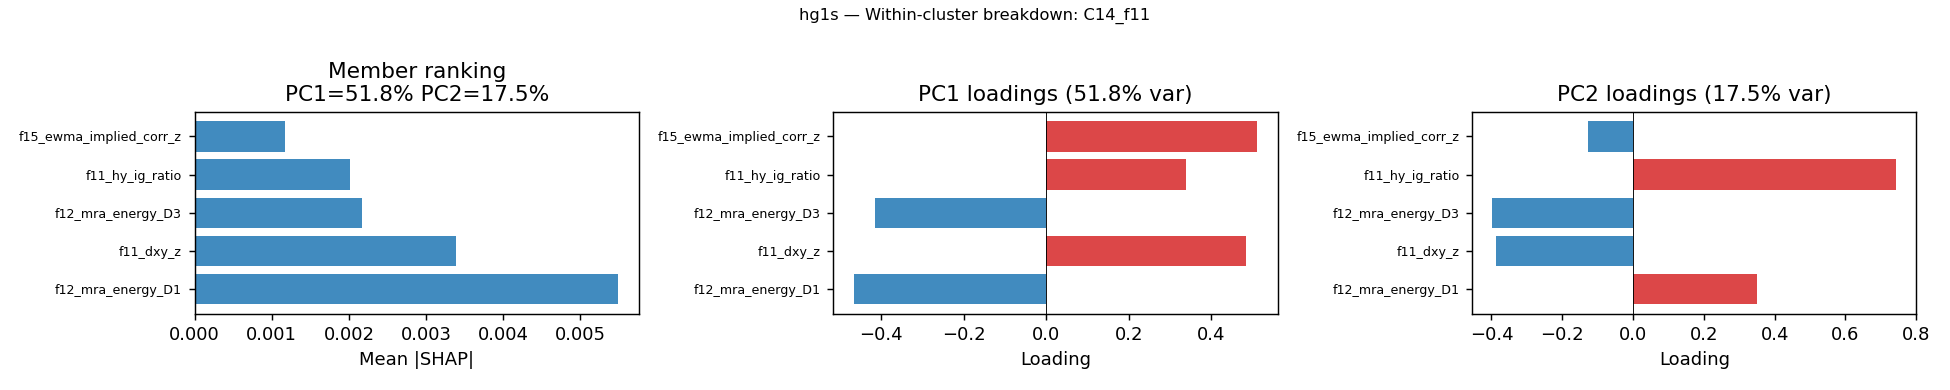

In [21]:
show_step3('hg1s')

#### Step 5 · Global feature importance

,feature,shap_magnitude,shap_signed,mdi
0,f1_mr_score_40,0.0061,0.0004,0.0258
1,f12_mra_energy_D1,0.0055,-0.0014,0.0314
2,f1_hilo_pos_10,0.0049,-0.0003,0.0307
3,f1_dist_ma_sigma_20,0.0048,0.0016,0.0259
4,f12_mra_energy_D4,0.0046,0.0006,0.0225
5,f1_rsi_14,0.0040,0.0002,0.0215
6,f2_vol_of_vol_20,0.0039,-0.0014,0.0171
7,f11_skew_z,0.0039,0.0008,0.0201
8,f1_dist_ma_sigma_10,0.0038,0.0002,0.0245
9,f11_gasoline_stock_surprise,0.0037,-0.0000,0.0195


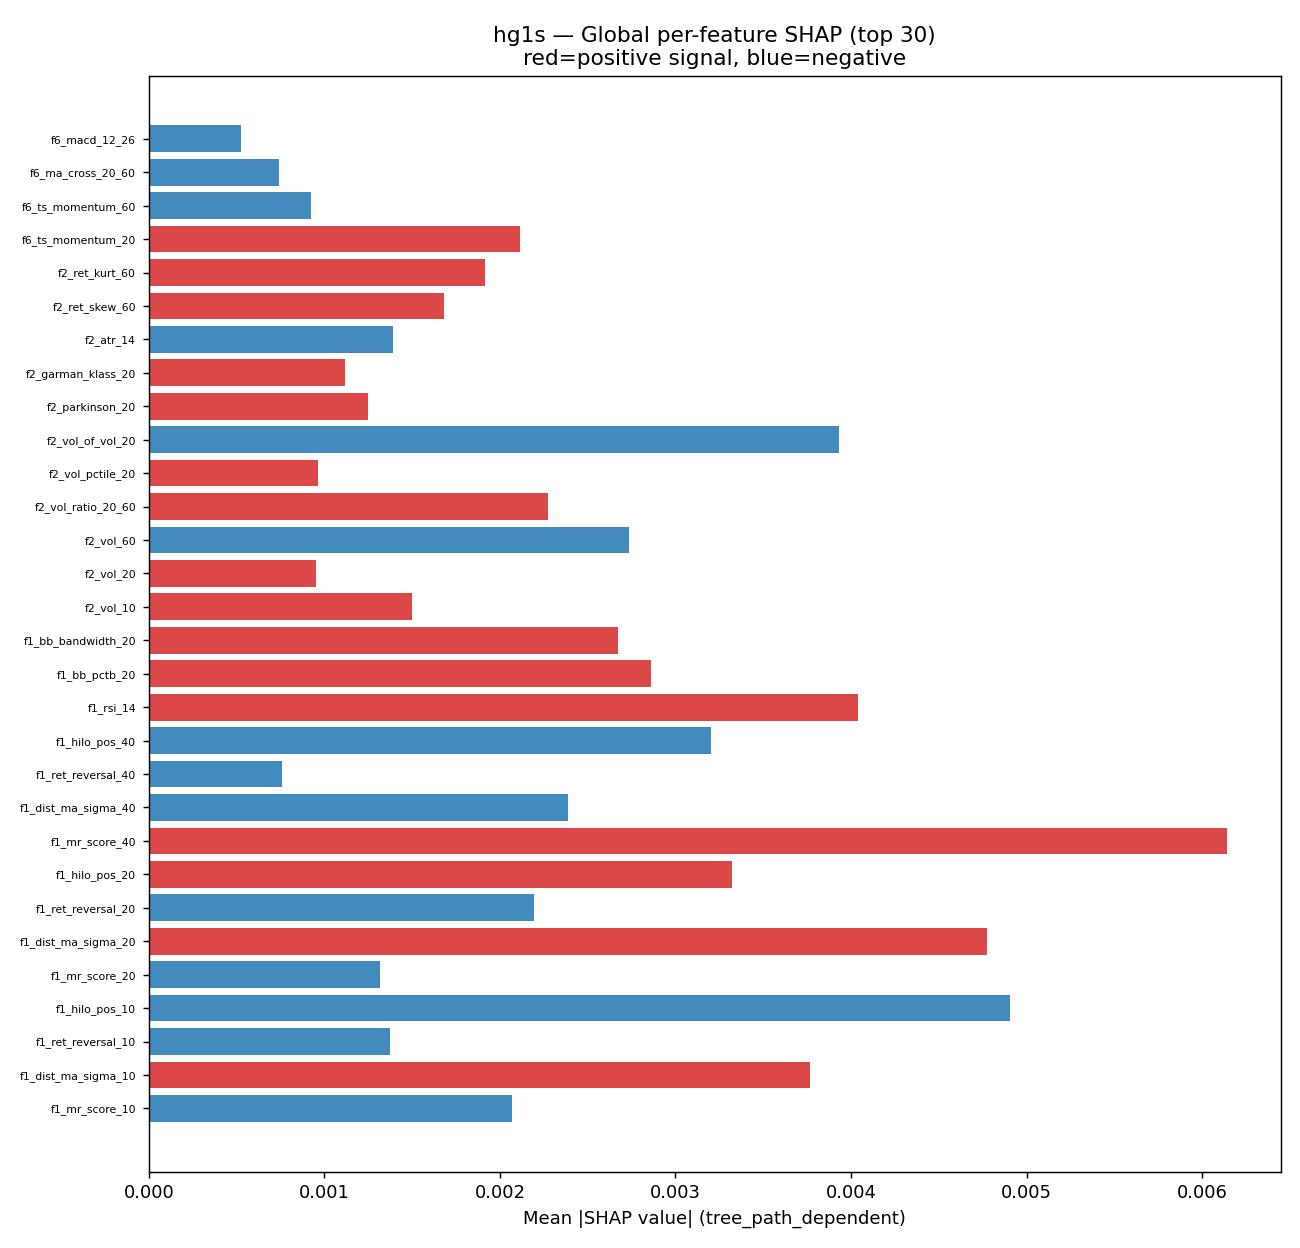

In [22]:
show_step5('hg1s')

---
## Cross-instrument findings — metals

In [23]:
# Cross-instrument summary — all values from champion_meta + clustered_mda_full
INSTS = ['gc1s', 'si1s', 'pl1s', 'hg1s']

rows = []
for inst in INSTS:
    m   = get_meta(inst)
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    ra  = load(BASE / inst / 'rank_agreement.csv')
    if not m:
        continue
    sig = mda[mda['significant']] if not mda.empty else pd.DataFrame()
    rows.append({
        'inst'          : inst,
        'group'         : m.get('group', '?'),
        'champion'      : m.get('model_type', '?').upper(),
        'family'        : m.get('family', '?'),
        'signal'        : '\u2713' if m.get('signal', False) else '\u2717',
        'AUC'           : f"{m.get('auc_mean', 0):.4f}\u00b1{m.get('auc_std', 0):.4f}",
        'lower_CI'      : f"{m.get('lower_ci', 0):.4f}",
        'n_sig_clusters': int(len(sig)),
        'top_cluster'   : mda.iloc[0]['cluster'] if not mda.empty else '?',
        'top_mda'       : f"{mda.iloc[0]['mean_drop']:.4f}" if not mda.empty else '?',
        '\u03c4_primary' : (f"{ra['kendall_tau'].iloc[0]:.2f}"
                           if not ra.empty else 'n/a'),
    })

summary = pd.DataFrame(rows).set_index('inst')
display(
    summary.style
    .set_caption('Metals champions — cross-instrument summary (all values computed)')
)

print('\nTop-5 MDA per instrument:')
for inst in INSTS:
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    m   = get_meta(inst)
    if mda.empty:
        continue
    tag = '' if m.get('signal', False) else ' (NO SIGNAL)'
    print(f'\n{inst.upper()}{tag}')
    print(mda[['cluster','mean_drop','std_drop','significant']].head(5).to_string(index=False))


,group,champion,family,signal,AUC,lower_CI,n_sig_clusters,top_cluster,top_mda,τ_primary
inst,,,,,,,,,,
gc1s,precious,RF,tree,✗,0.4866±0.1132,0.3734,0,C5_hmm_vol,0.0336,0.12
si1s,precious,RF,tree,✗,0.5400±0.0638,0.4762,0,C5_hmm_vol,0.0408,-0.05
pl1s,precious,RF,tree,✓,0.5697±0.0301,0.5396,2,C5_hmm_vol,0.0447,0.24
hg1s,hg1s,RF,tree,✓,0.5463±0.0405,0.5058,2,C1_f1,0.0212,0.27



Top-5 MDA per instrument:

GC1S (NO SIGNAL)
              cluster  mean_drop  std_drop  significant
           C5_hmm_vol   0.033574  0.067363        False
C10_f11_lowfreq_macro   0.012410  0.021660        False
                C2_f1   0.006728  0.017764        False
 C9_f11_lowfreq_macro   0.004325  0.018438        False
              C15_f11   0.001086  0.017188        False

SI1S (NO SIGNAL)
              cluster  mean_drop  std_drop  significant
           C5_hmm_vol   0.040807  0.051982        False
C15_f11_lowfreq_macro   0.007971  0.010660        False
C13_f11_lowfreq_macro   0.004720  0.006913        False
               C9_f13   0.002310  0.005306        False
               C10_f7   0.000303  0.005519        False

PL1S
              cluster  mean_drop  std_drop  significant
           C5_hmm_vol   0.044748  0.031769         True
              C11_f11   0.015163  0.014228         True
C15_f11_lowfreq_macro   0.011312  0.015681        False
          F8_calendar   0.005255  0

---
## Consistency assertions

In [24]:
# ── CONSISTENCY ASSERTIONS ─────────────────────────────────────────────────
# (a/b/c) champion_meta matches selection_table
# (d)     Step-3 cluster names == names in clustered_mda_full
# (e)     Step-3 cluster IDs exist in cluster_membership.csv
# (f)     AUC in champion_meta self-consistent (trivially true; verified here for completeness)

INSTS = ['gc1s', 'si1s', 'pl1s', 'hg1s']
errors = []

for inst in INSTS:
    s   = sel.loc[inst]
    m   = get_meta(inst)
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    mem = load(BASE / inst / 'cluster_membership.csv')

    if not m:
        errors.append(f'{inst}: champion_meta.csv missing or empty')
        continue

    # (a/b/c) model type
    meta_model, sel_model = m.get('model_type',''), s['best_model']
    if meta_model != sel_model:
        errors.append(
            f'{inst}: champion_meta model_type={meta_model!r} '
            f'!= selection_table best_model={sel_model!r}'
        )

    # AUC match
    meta_auc = round(float(m.get('auc_mean', -1)), 4)
    sel_auc  = round(float(s['best_auc']), 4)
    if abs(meta_auc - sel_auc) > 0.0001:
        errors.append(
            f'{inst}: champion_meta auc_mean={meta_auc} '
            f'!= selection_table best_auc={sel_auc}'
        )

    if mda.empty:
        errors.append(f'{inst}: clustered_mda_full.csv missing')
        continue

    # (d) Step-3 clusters come from the same MDA table
    step3   = top_n_clusters(inst, n=3)
    mda_set = set(mda['cluster'].tolist())
    for c in step3:
        if c not in mda_set:
            errors.append(f'{inst}: Step-3 cluster {c!r} not in clustered_mda_full.csv')

    # All significant clusters shown (assuming ≤ 3 significant)
    sig_set = set(mda[mda['significant']]['cluster'].tolist())
    shown   = set(step3)
    if len(sig_set) <= 3 and not sig_set.issubset(shown):
        missing = sig_set - shown
        errors.append(f'{inst}: significant clusters {missing} not shown in Step-3')

    # (e) cluster IDs exist in cluster_membership.csv
    if not mem.empty:
        mem_clusters = set(mem['cluster'].unique())
        for c in step3:
            if c not in mem_clusters:
                errors.append(f'{inst}: Step-3 cluster {c!r} not in cluster_membership.csv')

    # (f) AUC fields in champion_meta are internally consistent
    auc_m = m.get('auc_mean', float('nan'))
    lci_m = m.get('lower_ci', float('nan'))
    if not math.isnan(auc_m) and not math.isnan(lci_m) and lci_m > auc_m:
        errors.append(f'{inst}: lower_ci={lci_m} > auc_mean={auc_m} (impossible)')

if errors:
    print('ASSERTION FAILURES:')
    for e in errors:
        print(f'  \u2717 {e}')
    raise AssertionError(f'{len(errors)} assertion(s) failed — see above')
else:
    print(f'\u2713 All assertions passed for {INSTS}')


✓ All assertions passed for ['gc1s', 'si1s', 'pl1s', 'hg1s']
